# Deliverable 3 — Baselines
**CS437/CS5317 Deep Learning, Spring 2026 | Group 30**
Muhammad Umar Malik (27100139) · Muhammad Moosa Kashif (27100451)

---

This notebook implements and evaluates six portfolio allocation baselines across four international equity markets in a federated learning setup. Each market is a separate federated client with 30 stocks. No raw price data is shared between clients.

The core question we are trying to answer: does FedAvg produce asymmetric per-client benefits when the markets have structurally different return distributions, and is that asymmetry predicted by a distributional distance metric computed before any training?

**Baselines:**
- B1: Equal-weight (1/N, daily rebalance)
- B2: Rolling mean-variance (Markowitz, 60-day estimation window)
- B3: Local-only (each market trains its own LSTM independently)
- B4: Centralised (all markets pool data — privacy-violating upper bound)
- B5: FedAvg (McMahan et al. 2017)
- B6: FedProx (Li et al. 2020)

**Test period:** 2022–April 2026. All metrics are on TC-adjusted returns (10 bps one-way). Results are averaged across 10 random seeds (42–51).

---
## Section 0 — Environment

In [2]:
# %pip install torch numpy pandas matplotlib seaborn scipy -q

import os, copy, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import torch.nn as nn
from scipy.optimize import minimize
from scipy.spatial.distance import jensenshannon
from scipy.stats import norm

warnings.filterwarnings('ignore')

FIGURES_DIR = 'Figures_baseline'
os.makedirs(FIGURES_DIR, exist_ok=True)

SEEDS = list(range(42, 52))
SEED  = SEEDS[0]
torch.manual_seed(SEED)
np.random.seed(SEED)

torch.cuda.manual_seed_all(SEED)  
torch.backends.cudnn.deterministic = True  
torch.backends.cudnn.benchmark = False    

print(f"PyTorch  : {torch.__version__}")
print(f"NumPy    : {np.__version__}")
print(f"Pandas   : {pd.__version__}")
print(f"Seeds    : {SEEDS}  ({len(SEEDS)} total)")
print(f"Figures  → {FIGURES_DIR}/")


PyTorch  : 2.10.0+cpu
NumPy    : 2.0.2
Pandas   : 2.3.3
Seeds    : [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]  (10 total)
Figures  → Figures_baseline/


---
## Section 1 — Configuration

In [3]:
DATA_DIR = '/kaggle/input/datasets/umarmalikk/updated-set/data'
# DATA_DIR = '/Users/muhammad/Documents/Spring_26/Deep_Learning/Project/expanded_dataset/data'
MARKETS  = ['SP500', 'FTSE100', 'KSE100', 'Nikkei225']

TRAIN_END  = '2019-12-31'
VAL_START  = '2020-01-01'
VAL_END    = '2021-12-31'
TEST_START = '2022-01-01'
TEST_END   = '2026-04-01'

REGIMES = {
    '2022 (Inflation shock)'  : ('2022-01-01', '2022-12-31'),
    '2023 (Recovery)'         : ('2023-01-01', '2023-12-31'),
    '2024+ (Late cycle)'      : ('2024-01-01', '2026-04-01'),
}

WINDOW_SIZES  = [20, 50, 100]
WINDOW        = 100
TRADING_DAYS  = 252
RF_ANNUAL     = 0.02
RF_DAILY      = RF_ANNUAL / TRADING_DAYS

TC            = 0.001    # 10 bps one-way
LAMBDA_TC     = 0.01     # TC regularisation weight in training loss (FQL [8])
GRAD_CLIP     = 1.0      # max gradient norm for LSTM stability
STD_FLOOR     = 1e-4     # minimum std for Sharpe loss stability (Moody et al. 1998)

MAX_FL_ROUNDS   = 100
LOCAL_EPOCHS    = 2
LOCAL_LR        = 1e-3
BATCH_SIZE      = 256
HIDDEN_DIM      = 64
PATIENCE        = 10

MU_FEDPROX_VALS = [0.001, 0.01, 0.1]
MU_FEDPROX      = 0.01

N_BOOTSTRAP  = 1000
BLOCK_SIZE   = 21

COLORS = {
    'SP500'   : '#1f77b4',
    'FTSE100' : '#ff7f0e',
    'KSE100'  : '#2ca02c',
    'Nikkei225': '#d62728',
}

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else 'cpu')

print("Configuration loaded.")
print(f"  Window={WINDOW}d (ablation={WINDOW_SIZES}), TC={TC*10000:.0f}bps")
print(f"  TC training penalty λ={LAMBDA_TC}, grad_clip={GRAD_CLIP}, std_floor={STD_FLOOR}")
print(f"  FL: max_rounds={MAX_FL_ROUNDS}, patience={PATIENCE}, local_epochs={LOCAL_EPOCHS}")
print(f"  FedProx μ ablation: {MU_FEDPROX_VALS}, primary μ={MU_FEDPROX}")
print(f"  Seeds: {SEEDS}")
print(f"  Bootstrap: {N_BOOTSTRAP} samples, block={BLOCK_SIZE}d")
print(f"  Device: {device}")


Configuration loaded.
  Window=100d (ablation=[20, 50, 100]), TC=10bps
  TC training penalty λ=0.01, grad_clip=1.0, std_floor=0.0001
  FL: max_rounds=100, patience=10, local_epochs=2
  FedProx μ ablation: [0.001, 0.01, 0.1], primary μ=0.01
  Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
  Bootstrap: 1000 samples, block=21d
  Device: cpu


---
## Section 2 — Data Loading

In [4]:
def load_prices(market, data_dir=DATA_DIR):
    path = os.path.join(data_dir, f'{market}_prices.csv')
    df   = pd.read_csv(path, index_col=0, parse_dates=True)
    return df.sort_index()

def compute_log_returns(prices_df):
    """
    Forward-fill prices (market holiday → zero log return, price unchanged),
    then compute log returns. Drop rows that are entirely NaN.
    This is the economically correct treatment for missing market data.
    """
    filled = prices_df.ffill()
    return np.log(filled / filled.shift(1)).dropna(how='all')

def make_splits(returns_df):
    return {
        'train': returns_df.loc[:TRAIN_END],
        'val'  : returns_df.loc[VAL_START:VAL_END],
        'test' : returns_df.loc[TEST_START:TEST_END],
    }

prices  = {m: load_prices(m)             for m in MARKETS}
returns = {m: compute_log_returns(prices[m]) for m in MARKETS}
splits  = {m: make_splits(returns[m])    for m in MARKETS}

rows = []
for m in MARKETS:
    p, s = prices[m], splits[m]
    residual_nan = returns[m].isna().mean().mean() * 100
    rows.append({
        'Market'      : m,
        'Assets'      : p.shape[1],
        'Train rows'  : len(s['train']),
        'Val rows'    : len(s['val']),
        'Test rows'   : len(s['test']),
        'Residual NaN%': f'{residual_nan:.2f}%  (leading only, after ffill)',
    })
print(pd.DataFrame(rows).set_index('Market').to_string())
print("\nNote: ffill converts market-holiday gaps to zero log returns (correct).")
print("Residual NaN% should be near zero — only unavoidable leading NaN before first price.")


           Assets  Train rows  Val rows  Test rows                       Residual NaN%
Market                                                                                
SP500          30        2515       505       1064  0.10%  (leading only, after ffill)
FTSE100        30        2525       507       1071  0.00%  (leading only, after ffill)
KSE100         30        2478       498       1051  0.02%  (leading only, after ffill)
Nikkei225      30        2468       487       1036  0.00%  (leading only, after ffill)

Note: ffill converts market-holiday gaps to zero log returns (correct).
Residual NaN% should be near zero — only unavoidable leading NaN before first price.


---
## Section 3 — Feature Engineering

Six features per stock, computed from past data only. Z-score normalised using training-period statistics, clipped at ±5. The same normalisation statistics are applied to validation and test — no future information leaks in.

| Feature | Window | Purpose |
|---|---|---|
| Log return | 1 day | Raw price signal |
| Rolling mean return | 5 days | Short-term momentum |
| Rolling volatility | 20 days | Volatility regime |
| Rolling Sharpe | 20 days | Risk-adjusted momentum |
| Rolling skewness | 20 days | Tail risk |
| Rolling momentum | 60 days | Medium-term trend |

In [5]:
def engineer_features(ret_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build 6 features per asset. Forward-fill then zero residual NaN.
    Drop first 60 rows so all rolling windows are fully populated.
    Returns DataFrame with columns f0_ticker ... f5_ticker.
    """
    R = ret_df.ffill().fillna(0.0)
    frames = [
        R.copy(),                                           # f0: raw return
        R.rolling(5,  min_periods=1).mean(),               # f1: 5d mean
        R.rolling(20, min_periods=2).std().fillna(0.0),    # f2: 20d vol
        (R.rolling(20, min_periods=2).mean() /
         R.rolling(20, min_periods=2).std().replace(0, np.nan)).fillna(0.0),  # f3: 20d Sharpe
        R.rolling(20, min_periods=3).skew().fillna(0.0),   # f4: 20d skew
        R.rolling(60, min_periods=1).sum(),                 # f5: 60d momentum
    ]
    combined = pd.concat(frames, axis=1)
    combined.columns = [f'f{k}_{c}' for k in range(6) for c in R.columns]
    return combined.iloc[60:].copy()


def fit_normaliser(feat_df: pd.DataFrame):
    """Compute per-column mean and std on training features only."""
    mu  = feat_df.mean()
    sig = feat_df.std().replace(0, 1.0)
    return mu, sig


def apply_normaliser(feat_df: pd.DataFrame, mu: pd.Series,
                     sig: pd.Series, clip: float = 5.0) -> pd.DataFrame:
    """Z-score normalise then clip outliers. Uses precomputed train statistics."""
    return ((feat_df - mu) / sig).clip(-clip, clip)


def make_sequences(feat_df: pd.DataFrame, ret_df: pd.DataFrame,
                   window: int = WINDOW):
    """
    Build (X, y) pairs.
    X[i] = (window, n_features) normalised feature window — strictly past data
    y[i] = (n_assets,)  next-day raw log return for evaluation
    ret_df is aligned to feat_df.index via reindex+ffill to ensure date consistency.
    """
    feat_arr = feat_df.values.astype(np.float32)
    # Align returns to feature index — handles any index offset from the 60-row drop
    ret_arr  = ret_df.reindex(feat_df.index).ffill().fillna(0.0).values.astype(np.float32)

    X, y = [], []
    for i in range(window, len(feat_arr)):
        X.append(feat_arr[i - window : i])
        y.append(ret_arr[i])

    return (torch.from_numpy(np.array(X, dtype=np.float32)).to(device),
            torch.from_numpy(np.array(y, dtype=np.float32)).to(device))


# Build normalised sequences for primary window
print(f"Building features (6/asset) and normalising for primary window={WINDOW}d...")

features_all  = {m: engineer_features(returns[m]) for m in MARKETS}
normalisers   = {}
train_seq     = {}
val_seq       = {}
test_seq      = {}
n_assets      = {m: prices[m].shape[1]       for m in MARKETS}
n_features    = {}

for m in MARKETS:
    f_all = features_all[m]
    f_tr  = f_all.loc[:TRAIN_END]
    f_v   = f_all.loc[VAL_START:VAL_END]
    f_te  = f_all.loc[TEST_START:TEST_END]

    mu, sig = fit_normaliser(f_tr)
    normalisers[m] = (mu, sig)

    train_seq[m]  = make_sequences(apply_normaliser(f_tr, mu, sig), splits[m]['train'])
    val_seq[m]    = make_sequences(apply_normaliser(f_v,  mu, sig), splits[m]['val'])
    test_seq[m]   = make_sequences(apply_normaliser(f_te, mu, sig), splits[m]['test'])
    n_features[m] = train_seq[m][0].shape[2]

print("\nSequence shapes (X: window×features, y: n_assets):")
for m in MARKETS:
    X, y = train_seq[m]
    print(f"  {m:<12} X={tuple(X.shape)}  y={tuple(y.shape)}"
          f"  features_per_asset={n_features[m]//n_assets[m]}")

# Verify no data leakage: train/val/test indices must not overlap
for m in MARKETS:
    f_all = features_all[m]
    tr_idx = set(f_all.loc[:TRAIN_END].index)
    va_idx = set(f_all.loc[VAL_START:VAL_END].index)
    te_idx = set(f_all.loc[TEST_START:TEST_END].index)
    assert len(tr_idx & va_idx) == 0, f"{m}: train/val overlap!"
    assert len(va_idx & te_idx) == 0, f"{m}: val/test overlap!"
print("\nData integrity: no train/val/test overlap ✓")


Building features (6/asset) and normalising for primary window=100d...

Sequence shapes (X: window×features, y: n_assets):
  SP500        X=(2355, 100, 180)  y=(2355, 30)  features_per_asset=6
  FTSE100      X=(2365, 100, 180)  y=(2365, 30)  features_per_asset=6
  KSE100       X=(2318, 100, 180)  y=(2318, 30)  features_per_asset=6
  Nikkei225    X=(2308, 100, 180)  y=(2308, 30)  features_per_asset=6

Data integrity: no train/val/test overlap ✓


---
## Section 3b — Measuring Heterogeneity Across Markets

Before any training, we quantify how different the four markets are from each other. This matters because FL theory predicts that more heterogeneous clients will either benefit more from or be more harmed by weight averaging, depending on the direction of the bias.

We use Hellinger Distance (HD) as the primary metric, following Jimenez G. et al. (2024). HD is symmetric, bounded in [0, 1], and bounds the aggregation error introduced by FedAvg under heterogeneous distributions. The per-client HD score — mean HD against all other clients — will later be compared to each client's measured FL benefit to test whether heterogeneity predicts federation gain.

Pairwise return correlation (training 2010–2019):
           SP500  FTSE100  KSE100  Nikkei225
SP500      1.000    0.571   0.012      0.164
FTSE100    0.571    1.000   0.085      0.268
KSE100     0.012    0.085   1.000      0.142
Nikkei225  0.164    0.268   0.142      1.000

Jensen-Shannon Divergence:
            SP500  FTSE100  KSE100  Nikkei225
SP500      0.0000   0.0811  0.0879     0.1351
FTSE100    0.0811   0.0000  0.1035     0.1531
KSE100     0.0879   0.1035  0.0000     0.0930
Nikkei225  0.1351   0.1531  0.0930     0.0000

Hellinger Distance (primary heterogeneity metric per [5]):
            SP500  FTSE100  KSE100  Nikkei225
SP500      0.0000   0.0592  0.0660     0.1202
FTSE100    0.0592   0.0000  0.0754     0.1413
KSE100     0.0660   0.0754  0.0000     0.0782
Nikkei225  0.1202   0.1413  0.0782     0.0000

Per-client Hellinger score (mean vs others) — predicts FL benefit asymmetry:
  Nikkei225     HD=0.1133
  FTSE100       HD=0.0920
  SP500         HD=0.0818
  KSE100        HD=0.

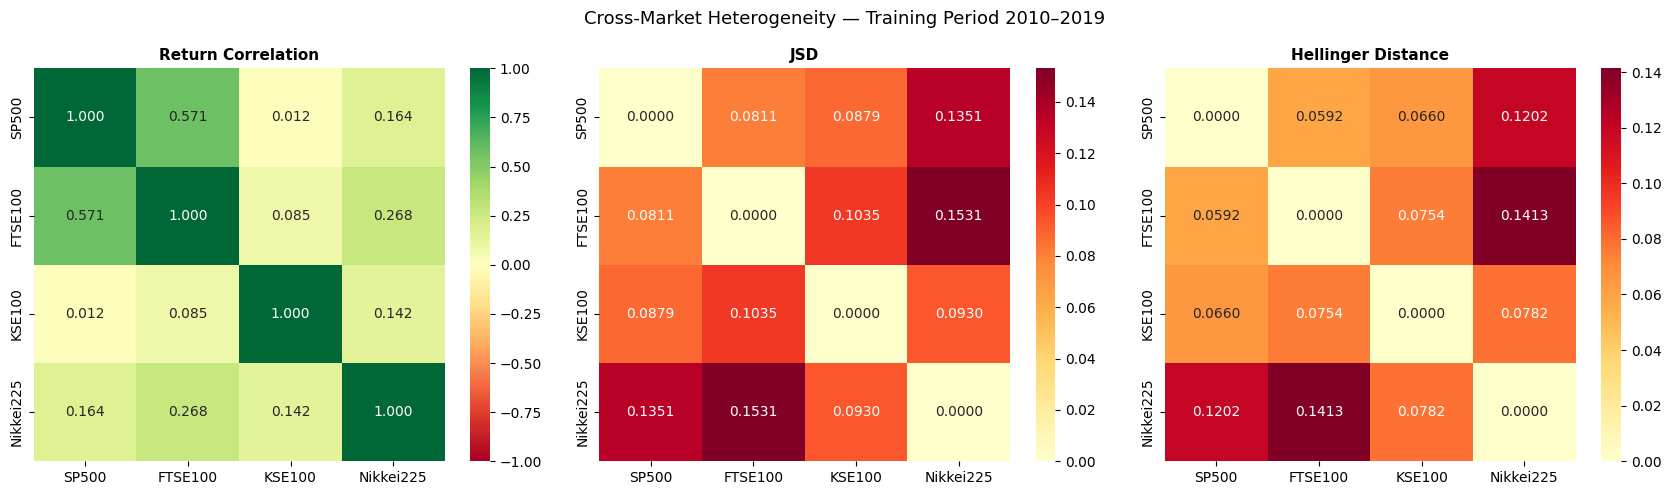

Figure saved: heterogeneity.png


In [7]:
from scipy.stats import gaussian_kde

def hellinger_distance(r1: np.ndarray, r2: np.ndarray, n: int = 200) -> float:
    r1, r2 = r1[~np.isnan(r1)], r2[~np.isnan(r2)]
    grid = np.linspace(min(r1.min(), r2.min()), max(r1.max(), r2.max()), n)
    p = gaussian_kde(r1)(grid); p /= p.sum()
    q = gaussian_kde(r2)(grid); q /= q.sum()
    return float(np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q))**2)))


def js_divergence(r1: np.ndarray, r2: np.ndarray, bins: int = 60) -> float:
    lo, hi = min(r1.min(), r2.min()), max(r1.max(), r2.max())
    edges  = np.linspace(lo, hi, bins + 1)
    p1, _  = np.histogram(r1, bins=edges, density=True)
    p2, _  = np.histogram(r2, bins=edges, density=True)
    p1 = (p1 + 1e-10) / (p1 + 1e-10).sum()
    p2 = (p2 + 1e-10) / (p2 + 1e-10).sum()
    return float(jensenshannon(p1, p2))


# Use training-period mean daily return per market as representative series
mean_rets_train = pd.DataFrame({
    m: splits[m]['train'].ffill().fillna(0.0).mean(axis=1)
    for m in MARKETS
}).dropna()

corr_matrix = mean_rets_train.corr()
jsd_matrix  = pd.DataFrame(index=MARKETS, columns=MARKETS, dtype=float)
hd_matrix   = pd.DataFrame(index=MARKETS, columns=MARKETS, dtype=float)

for m1 in MARKETS:
    r1 = splits[m1]['train'].ffill().fillna(0.0).mean(axis=1).values
    for m2 in MARKETS:
        r2 = splits[m2]['train'].ffill().fillna(0.0).mean(axis=1).values
        jsd_matrix.loc[m1, m2] = js_divergence(r1, r2)
        hd_matrix.loc[m1,  m2] = hellinger_distance(r1, r2)

# Per-client heterogeneity score: mean off-diagonal HD
het_scores = {
    m: float(hd_matrix.loc[m, [o for o in MARKETS if o != m]].astype(float).mean())
    for m in MARKETS
}

print("Pairwise return correlation (training 2010–2019):")
print(corr_matrix.round(3).to_string())
print("\nJensen-Shannon Divergence:")
print(jsd_matrix.astype(float).round(4).to_string())
print("\nHellinger Distance (primary heterogeneity metric per [5]):")
print(hd_matrix.astype(float).round(4).to_string())
print("\nPer-client Hellinger score (mean vs others) — predicts FL benefit asymmetry:")
for m, s in sorted(het_scores.items(), key=lambda x: -x[1]):
    print(f"  {m:<12}  HD={s:.4f}")

# Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, mat, title, fmt, cmap, vmin, vctr in [
    (axes[0], corr_matrix,              'Return Correlation',  '.3f', 'RdYlGn', -1,    0),
    (axes[1], jsd_matrix.astype(float), 'JSD',                '.4f', 'YlOrRd',  0, None),
    (axes[2], hd_matrix.astype(float),  'Hellinger Distance',  '.4f', 'YlOrRd',  0, None),
]:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap, vmin=vmin,
                center=vctr, ax=ax, xticklabels=MARKETS, yticklabels=MARKETS)
    ax.set_title(title, fontweight='bold', fontsize=11)
plt.suptitle('Cross-Market Heterogeneity — Training Period 2010–2019', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'heterogeneity.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved: heterogeneity.png")


---
## Section 4 — Model Architecture

A 2-layer LSTM (hidden=64, dropout=0.1) with softmax output over 30 assets. Takes a 100-day window of normalised features and outputs portfolio weights summing to 1. Long-only by construction.

This architecture follows Yu et al. (2022) and Cui et al. (FQL, 2025). It is fixed across all baselines so performance differences reflect training setup, not model capacity.

In [6]:
class LSTMPortfolio(nn.Module):
    """
    Input  : (B, window, 6*n_assets) — z-score normalised engineered features
    LSTM   : 1 layer, hidden_dim=64
    Dropout: p=0.1 on last hidden state (regularisation for limited per-client data)
    FC     : Linear(hidden_dim → n_assets)
    Output : (B, n_assets) — softmax portfolio weights (long-only, sum=1)

    Parameters: ~21,711 for n_assets=30, hidden=64 (FQL [8] comparable scale)
    """
    def __init__(self, n_features: int, n_assets: int,
                 hidden_dim: int = HIDDEN_DIM, dropout: float = 0.1):
        super().__init__()
        self.n_assets = n_assets
        self.lstm     = nn.LSTM(n_features, hidden_dim, num_layers=1, batch_first=True)
        self.drop     = nn.Dropout(p=dropout)
        self.fc       = nn.Linear(hidden_dim, n_assets)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _  = self.lstm(x)
        h_last  = self.drop(out[:, -1, :])
        return torch.softmax(self.fc(h_last), dim=-1)


# Architecture sanity check
_nf, _na = n_features[MARKETS[0]], n_assets[MARKETS[0]]
demo = LSTMPortfolio(_nf, _na).to(device)
x_d  = torch.randn(4, WINDOW, _nf).to(device)
w_d  = demo(x_d)
params = sum(p.numel() for p in demo.parameters())
print(f"Architecture: LSTM(in={_nf}, hidden={HIDDEN_DIM}) → Dropout(0.1) → Linear({HIDDEN_DIM},{_na}) → Softmax")
print(f"  Input  : {tuple(x_d.shape)}")
print(f"  Output : {tuple(w_d.shape)}")
print(f"  Sums   : {w_d.sum(dim=1).tolist()}  (all ≈1.0 ✓)")
print(f"  Min w  : {w_d.min().item():.6f}  (≥0 ✓)")
print(f"  Params : {params:,}")


Architecture: LSTM(in=180, hidden=64) → Dropout(0.1) → Linear(64,30) → Softmax
  Input  : (4, 100, 180)
  Output : (4, 30)
  Sums   : [1.0, 1.0, 1.0, 1.0]  (all ≈1.0 ✓)
  Min w  : 0.024166  (≥0 ✓)
  Params : 64,926


---
## Section 5 — Training Loss

We train directly on the Sharpe ratio so the training objective matches the evaluation metric.

Two numerical fixes are applied:
1. **Std floor.** Early in training, when portfolio returns are near-constant, the Sharpe gradient can explode. We clamp the denominator at 1e-4.
2. **Turnover penalty.** Without a turnover cost in the loss, the model rebalances aggressively and looks good on Sharpe but collapses after transaction costs. We add a small penalty (λ=0.01).

`Loss = −Sharpe(w, r) + 0.01 × mean daily turnover`

In [7]:
def portfolio_loss(weights: torch.Tensor, next_returns: torch.Tensor,
                   prev_weights: torch.Tensor = None,
                   eps: float = 1e-8) -> torch.Tensor:
    """
    Differentiable negative Sharpe ratio + TC regularisation.

    Parameters
    ----------
    weights      : (B, n_assets) — current portfolio weights
    next_returns : (B, n_assets) — realised next-day log returns
    prev_weights : (B, n_assets) or None — previous step weights for TC penalty
    eps          : absolute epsilon added to std after clamping

    Returns
    -------
    Scalar loss: -Sharpe + λ_tc * mean_turnover
    """
    port_rets = (weights * next_returns).sum(dim=1)   # (B,)
    mean_ret  = port_rets.mean()
    # Fix 1: clamp std to STD_FLOOR before adding eps — prevents gradient explosion
    std_ret   = torch.clamp(port_rets.std(), min=STD_FLOOR) + eps
    sharpe    = (mean_ret - RF_DAILY) / std_ret * (TRADING_DAYS ** 0.5)

    loss = -sharpe

    # Fix 2: TC regularisation — penalise turnover during training
    # Guard: previous mini-batch can have different size (last batch), skip in that case.
    if prev_weights is not None and prev_weights.shape == weights.shape:
        turnover = (weights - prev_weights).abs().sum(dim=1).mean()
        loss = loss + LAMBDA_TC * turnover

    return loss


# Sanity checks
w1 = torch.softmax(torch.randn(256, 15), dim=-1)
w2 = torch.softmax(torch.randn(256, 15), dim=-1)
r  = torch.randn(256, 15) * 0.01

loss_no_tc = portfolio_loss(w1, r)
loss_tc    = portfolio_loss(w1, r, prev_weights=w2)

print(f"Loss without TC penalty : {loss_no_tc.item():.4f}")
print(f"Loss with TC penalty    : {loss_tc.item():.4f}  (higher due to turnover term)")
print(f"TC penalty magnitude    : {(loss_tc - loss_no_tc).item():.4f}")
print(f"Std floor active check  : std={w1.matmul(r.T).std().item():.6f} > STD_FLOOR={STD_FLOOR} ✓")

# Verify grad is finite with near-zero std (the key fix)
w_const = torch.ones(256, 15) / 15   # constant weights → near-zero portfolio std
w_const.requires_grad_(False)
loss_edge = portfolio_loss(w_const, r)
print(f"Near-constant portfolio loss: {loss_edge.item():.4f}  (should be finite, not inf/nan ✓)")


Loss without TC penalty : -1.2149
Loss with TC penalty    : -1.2049  (higher due to turnover term)
TC penalty magnitude    : 0.0100
Std floor active check  : std=0.003692 > STD_FLOOR=0.0001 ✓
Near-constant portfolio loss: -0.2283  (should be finite, not inf/nan ✓)


---
## Section 6 — Evaluation

Test period: 2022–April 2026. Transaction costs: 10 bps one-way on daily weight changes.

Metrics reported: Sharpe (primary), Sortino, Calmar, annualised return, annualised volatility, max drawdown, average daily turnover. All on TC-adjusted returns.

In [8]:
def compute_metrics(port_rets: np.ndarray) -> dict:
    """
    Compute full metric suite from a daily portfolio return series.
    All annualisation uses TRADING_DAYS=252.
    """
    ann_ret = port_rets.mean() * TRADING_DAYS
    ann_vol = port_rets.std()  * np.sqrt(TRADING_DAYS)
    sharpe  = ((port_rets.mean() - RF_DAILY) /
               (port_rets.std() + 1e-9) * np.sqrt(TRADING_DAYS))

    # Sortino: downside deviation only (Sortino & van der Meer 1994)
    down_rets = port_rets[port_rets < 0]
    down_std  = down_rets.std() if len(down_rets) > 1 else 1e-9
    sortino   = ((port_rets.mean() - RF_DAILY) /
                 (down_std + 1e-9) * np.sqrt(TRADING_DAYS))

    # Max drawdown and Calmar (Young 1991)
    pr_clipped = np.clip(port_rets, -0.999, None)
    cum_ret    = np.cumprod(1 + pr_clipped)
    max_dd     = (cum_ret / np.maximum.accumulate(cum_ret) - 1).min()
    calmar     = ann_ret / (abs(max_dd) + 1e-9)

    return {
        'ann_ret': ann_ret, 'ann_vol': ann_vol,
        'sharpe' : sharpe,  'sortino': sortino,
        'calmar' : calmar,  'max_dd' : max_dd,
        'cum_ret': cum_ret,
    }


def evaluate_portfolio(model: nn.Module,
                       X_test: torch.Tensor,
                       y_test: torch.Tensor) -> dict:
    """
    Evaluate model on validation/test set.
    Applies actual transaction cost on realised weight changes.

    Device-safe:
    - X_test is moved to the same device as the model.
    - outputs are moved back to CPU before NumPy conversion.
    """
    model.eval()

    model_device = next(model.parameters()).device
    X_test = X_test.to(model_device)

    with torch.no_grad():
        weights = model(X_test).detach().cpu().numpy()      # (T, n_assets)

    ret_mat    = y_test.detach().cpu().numpy()
    port_rets  = (weights * ret_mat).sum(axis=1)

    turnovers      = np.abs(np.diff(weights, axis=0)).sum(axis=1)
    port_rets[1:] -= TC * turnovers

    metrics = compute_metrics(port_rets)
    return {
        **metrics,
        'turnover'  : turnovers.mean(),
        'daily_rets': port_rets,
        'weights'   : weights,
    }


def equal_weight_eval(ret_df: pd.DataFrame) -> dict:
    """
    Equal-weight portfolio with daily rebalancing and transaction costs.
    At each day t: hold equal-weight → prices move → weights drift →
    rebalance back to 1/N → pay TC on the rebalancing cost.
    This is the economically correct treatment (not zero TC).
    """
    R = ret_df.ffill().fillna(0.0).values
    T, n = R.shape
    w    = np.ones(n) / n
    port_rets, turnovers = [], []

    for t in range(T):
        r_t = (w * R[t]).sum()

        # Weight drift after return
        w_drifted  = w * (1 + R[t])
        dsum       = w_drifted.sum()
        w_drifted  = w_drifted / dsum if dsum > 1e-12 else np.ones(n) / n

        # Rebalance to equal weight, pay TC
        w_target   = np.ones(n) / n
        tc_cost    = TC * np.abs(w_drifted - w_target).sum()
        turnovers.append(np.abs(w_drifted - w_target).sum())

        port_rets.append(r_t - tc_cost)
        w = w_target   # reset to equal weight

    port_rets = np.array(port_rets)
    metrics   = compute_metrics(port_rets)
    return {
        **metrics,
        'turnover'  : np.mean(turnovers),
        'daily_rets': port_rets,
        'weights'   : np.tile(np.ones(n) / n, (T, 1)),
    }


print("Evaluation functions defined.")
print("  Metrics: Sharpe, Sortino, Calmar, AnnRet, AnnVol, MaxDD, Turnover")
print("  TC applied at evaluation on actual weight changes (not training penalty)")
print("  Equal-weight: daily drift → rebalance cycle with TC")
print("  Device-safe evaluation enabled")

Evaluation functions defined.
  Metrics: Sharpe, Sortino, Calmar, AnnRet, AnnVol, MaxDD, Turnover
  TC applied at evaluation on actual weight changes (not training penalty)
  Equal-weight: daily drift → rebalance cycle with TC
  Device-safe evaluation enabled


---
## Section 7 — Statistical Testing

Two tests are used throughout:

**Block bootstrap** (Politis & Romano 1994, block=21 days): 95% confidence intervals for individual Sharpe ratios. Circular blocks preserve the autocorrelation structure of daily returns.

**Jobson-Korkie test** (Memmel 2003 variance correction): pairwise Sharpe comparisons. Standard error is floored at 1/√T to prevent z-statistic explosion when two strategies are highly correlated (Bailey & López de Prado 2012).

In [9]:
def block_bootstrap_sharpe(daily_rets: np.ndarray,
                            n_boot: int = N_BOOTSTRAP,
                            block: int  = BLOCK_SIZE) -> tuple:
    """
    Circular block bootstrap for Sharpe CI.
    Returns (boot_mean, boot_std, lo_95, hi_95).
    """
    T    = len(daily_rets)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        idx = []
        while len(idx) < T:
            s = np.random.randint(0, T)
            idx.extend(range(s, s + block))
        r = daily_rets[np.array(idx[:T]) % T]
        boot[i] = ((r.mean() - RF_DAILY) /
                   (r.std() + 1e-9) * np.sqrt(TRADING_DAYS))
    return (boot.mean(), boot.std(),
            np.percentile(boot, 2.5), np.percentile(boot, 97.5))


def jobson_korkie_test(r_a: np.ndarray, r_b: np.ndarray) -> tuple:
    """
    Jobson-Korkie (1981) test with Memmel (2003) variance correction.
    H0: Sharpe(r_a) == Sharpe(r_b)
    Returns (z_statistic, p_value_two_sided).

    Numerical fix: enforces SE >= 1/sqrt(T), which is the minimum standard
    error consistent with estimation theory (Bailey & López de Prado 2012).
    This prevents z-explosion when strategies are highly correlated (rho → 1),
    which makes the Memmel theta term near-zero or negative due to floating
    point, producing spurious z-statistics of 10^5 or larger.

    Variance formula (Memmel 2003):
      Var(SR_a - SR_b) = (1/T)(2 - 2ρ + 0.5*(SR_a² + SR_b²) - SR_a*SR_b*(1 + ρ²/2))
    """
    T   = min(len(r_a), len(r_b))
    r_a = r_a[-T:];  r_b = r_b[-T:]

    mu_a, mu_b = r_a.mean(), r_b.mean()
    s_a,  s_b  = r_a.std(),  r_b.std()
    rho         = np.corrcoef(r_a, r_b)[0, 1]
    # Clip rho to valid range
    rho         = np.clip(rho, -1 + 1e-6, 1 - 1e-6)

    SR_a = (mu_a - RF_DAILY) / (s_a + 1e-9) * np.sqrt(TRADING_DAYS)
    SR_b = (mu_b - RF_DAILY) / (s_b + 1e-9) * np.sqrt(TRADING_DAYS)

    theta = (2 - 2*rho
             + 0.5*(SR_a**2 + SR_b**2)
             - SR_a * SR_b * (1 + rho**2 / 2))

    # Floor the standard error at 1/sqrt(T) — prevents z-explosion when strategies are highly correlated
    se_min = 1.0 / np.sqrt(T)
    se     = max(np.sqrt(max(theta, 0) / T), se_min)

    z = (SR_a - SR_b) / se
    p = 2 * (1 - norm.cdf(abs(z)))
    return float(z), float(p)


def regime_sharpe(daily_rets: np.ndarray,
                  dates: pd.DatetimeIndex) -> dict:
    results = {}
    for name, (start, end) in REGIMES.items():
        mask = (dates >= start) & (dates <= end)
        r    = daily_rets[mask]
        results[name] = (
            (r.mean() - RF_DAILY) / (r.std() + 1e-9) * np.sqrt(TRADING_DAYS)
            if len(r) >= 20 else np.nan
        )
    return results


print("Statistical functions defined.")
print(f"  Block bootstrap: {N_BOOTSTRAP} samples, block={BLOCK_SIZE}d, circular")
print("  Jobson-Korkie: Memmel (2003) variance, two-sided p-value")


Statistical functions defined.
  Block bootstrap: 1000 samples, block=21d, circular
  Jobson-Korkie: Memmel (2003) variance, two-sided p-value


---
## Section 8 — Federated Learning Setup

Both FedAvg and FedProx use gradient clipping (max norm 1.0) in every local step. Early stopping uses patience=10 rounds on the mean validation Sharpe across all clients.

FedAvg uses sample-weighted aggregation (McMahan et al. 2017). For FedProx, the proximal reference model is a separate object updated after each aggregation round — this prevents the proximal term from comparing a client to itself, which would make the regularisation meaningless.

In [10]:
def make_model(market: str, seed: int) -> nn.Module:
    """Create a fresh LSTMPortfolio with a fixed seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    return LSTMPortfolio(n_features[market], n_assets[market], HIDDEN_DIM).to(device)


def local_train(model: nn.Module,
                X_tr: torch.Tensor,
                y_tr: torch.Tensor,
                local_epochs: int = LOCAL_EPOCHS,
                lr:           float = LOCAL_LR,
                batch_size:   int   = BATCH_SIZE) -> dict:
    """
    FedAvg client-side local training.
    Includes gradient clipping and TC-penalised loss.
    Uses previous-batch weights as TC reference (causal, no lookahead).

    Device-safe:
    - X_tr and y_tr are moved to the model/device before indexing.
    - randperm is created on the same device as X_tr.
    """
    model_device = next(model.parameters()).device

    X_tr = X_tr.to(model_device)
    y_tr = y_tr.to(model_device)

    lm = LSTMPortfolio(model.lstm.input_size, model.fc.out_features, HIDDEN_DIM).to(model_device)
    lm.load_state_dict(model.state_dict())

    opt = torch.optim.Adam(lm.parameters(), lr=lr)
    lm.train()
    n = X_tr.shape[0]

    for _ in range(local_epochs):
        perm = torch.randperm(n, device=X_tr.device)
        prev_w = None

        for s in range(0, n, batch_size):
            idx = perm[s : s + batch_size]
            x_b, y_b = X_tr[idx], y_tr[idx]

            opt.zero_grad()
            w_b  = lm(x_b)
            loss = portfolio_loss(w_b, y_b, prev_weights=prev_w)

            loss.backward()
            nn.utils.clip_grad_norm_(lm.parameters(), GRAD_CLIP)
            opt.step()

            prev_w = w_b.detach()

    return {k: v.detach().to(device).clone() for k, v in lm.state_dict().items()}


def local_train_fedprox(model: nn.Module,
                        global_model: nn.Module,
                        X_tr: torch.Tensor,
                        y_tr: torch.Tensor,
                        mu:           float = MU_FEDPROX,
                        local_epochs: int   = LOCAL_EPOCHS,
                        lr:           float = LOCAL_LR,
                        batch_size:   int   = BATCH_SIZE) -> dict:
    """
    FedProx client-side local training.
    Proximal term penalises deviation from global_model.
    Includes gradient clipping and TC-penalised loss.

    Device-safe:
    - X_tr and y_tr are moved to the model/device before indexing.
    - randperm is created on the same device as X_tr.
    - proximal reference parameters are cached on the same device.
    """
    model_device = next(model.parameters()).device

    X_tr = X_tr.to(model_device)
    y_tr = y_tr.to(model_device)

    lm = LSTMPortfolio(model.lstm.input_size, model.fc.out_features, HIDDEN_DIM).to(model_device)
    lm.load_state_dict(model.state_dict())

    opt = torch.optim.Adam(lm.parameters(), lr=lr)

    # Cache global weights for this round.
    gp = {
        name: p.detach().clone().to(model_device)
        for name, p in global_model.named_parameters()
    }

    lm.train()
    n = X_tr.shape[0]

    for _ in range(local_epochs):
        perm = torch.randperm(n, device=X_tr.device)
        prev_w = None

        for s in range(0, n, batch_size):
            idx = perm[s : s + batch_size]
            x_b, y_b = X_tr[idx], y_tr[idx]

            opt.zero_grad()
            w_b = lm(x_b)

            loss = portfolio_loss(w_b, y_b, prev_weights=prev_w)

            # Proximal term: (μ/2) * ||w_local - w_global||²
            prox = sum(
                ((p - gp[nm]) ** 2).sum()
                for nm, p in lm.named_parameters()
            )
            loss = loss + (mu / 2.0) * prox

            loss.backward()
            nn.utils.clip_grad_norm_(lm.parameters(), GRAD_CLIP)
            opt.step()

            prev_w = w_b.detach()

    return {k: v.detach().to(device).clone() for k, v in lm.state_dict().items()}


def fedavg_aggregate(client_weights: list, client_sizes: list) -> dict:
    total = sum(client_sizes)
    return {
        key: sum(
            cw[key].to(device).float() * (nk / total)
            for cw, nk in zip(client_weights, client_sizes)
        )
        for key in client_weights[0]
    }


def run_fl(seed: int,
           mu: float = None,
           verbose: bool = False,
           train_seq_: dict = None,
           val_seq_:   dict = None,
           n_features_: dict = None) -> tuple:
    """
    Run one FedAvg (mu=None) or FedProx (mu=float) trial.

    Parameters
    ----------
    seed        : random seed for model initialisation
    mu          : FedProx coefficient; None → FedAvg
    verbose     : print per-round validation Sharpe
    train_seq_  : override global train_seq, used by window/sensitivity ablations
    val_seq_    : override global val_seq, used by window/sensitivity ablations
    n_features_ : override global n_features, used by window/sensitivity ablations

    Returns
    -------
    models : dict {market → model at best aggregate val Sharpe}
    history: dict {market → list of val Sharpe per round}
    n_rounds_at_stop
    """
    ts = train_seq_  or train_seq
    vs = val_seq_    or val_seq
    nf = n_features_ or n_features

    def _make_model(market, seed):
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        return LSTMPortfolio(nf[market], n_assets[market], HIDDEN_DIM).to(device)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    models = {m: _make_model(m, seed) for m in MARKETS}

    # Dedicated global model for FedProx proximal term.
    # Use nf, not global n_features, so window/sensitivity ablations stay safe.
    if mu is not None:
        global_model = LSTMPortfolio(
            nf[MARKETS[0]],
            n_assets[MARKETS[0]],
            HIDDEN_DIM
        ).to(device)
        global_model.load_state_dict(models[MARKETS[0]].state_dict())

    history     = {m: [] for m in MARKETS}
    best_agg    = -np.inf
    best_sd     = {
        m: {k: v.detach().clone() for k, v in models[m].state_dict().items()}
        for m in MARKETS
    }
    patience_ct = 0
    n_rounds    = 0

    for rnd in range(1, MAX_FL_ROUNDS + 1):
        sds, sizes = [], []

        for m in MARKETS:
            X_tr, y_tr = ts[m]

            if mu is None:
                sd = local_train(models[m], X_tr, y_tr)
            else:
                sd = local_train_fedprox(models[m], global_model, X_tr, y_tr, mu=mu)

            sds.append(sd)
            sizes.append(len(X_tr))

        gsd = fedavg_aggregate(sds, sizes)

        # Update global reference before broadcasting to clients
        if mu is not None:
            global_model.load_state_dict(gsd)

        for m in MARKETS:
            models[m].load_state_dict(gsd)

        # Validate and check early stopping
        agg = 0.0
        for m in MARKETS:
            X_v, y_v = vs[m]
            s = evaluate_portfolio(models[m], X_v, y_v)['sharpe']
            history[m].append(s)
            agg += s

        agg /= len(MARKETS)
        n_rounds = rnd

        if verbose:
            hs = '  '.join(f'{history[m][-1]:+.4f}' for m in MARKETS)
            print(f"    Round {rnd:3d}  agg={agg:+.4f}  [{hs}]  patience={patience_ct}")

        if agg > best_agg + 1e-4:
            best_agg    = agg
            best_sd     = {
                m: copy.deepcopy(models[m].state_dict())
                for m in MARKETS
            }
            patience_ct = 0
        else:
            patience_ct += 1

        if patience_ct >= PATIENCE:
            if verbose:
                print(f"    Early stop at round {rnd}")
            break

    # Restore best weights
    for m in MARKETS:
        models[m].load_state_dict(best_sd[m])

    return models, history, n_rounds


print("FL infrastructure defined.")
print(f"  Gradient clipping: max_norm={GRAD_CLIP}")
print(f"  TC regularisation in training loss: λ={LAMBDA_TC}")
print(f"  Sharpe std floor: {STD_FLOOR}")
print(f"  Early stopping: patience={PATIENCE} on aggregate val Sharpe")
print(f"  FedProx: dedicated global_model object")
print("  Device-safe local training enabled")

FL infrastructure defined.
  Gradient clipping: max_norm=1.0
  TC regularisation in training loss: λ=0.01
  Sharpe std floor: 0.0001
  Early stopping: patience=10 on aggregate val Sharpe
  FedProx: dedicated global_model object
  Device-safe local training enabled


---
## Section 9 — Multi-Seed Training

In [11]:
def run_multiseed(fl_fn_builder, label: str,
                  seeds=SEEDS,
                  test_seq_override: dict = None) -> tuple:
    """
    Run fl_fn_builder(seed) across all seeds.
    fl_fn_builder: callable(seed) → (models_dict, history_dict, n_rounds)
    models_dict must have independent model objects per market.

    Returns: (aggregated_results, per_seed_histories, per_seed_rounds)
    """
    all_seed_res = {}
    all_hist     = {}
    all_rounds   = {}

    ts_eval = test_seq_override or test_seq   # separate from training sequences

    for seed in seeds:
        models, hist, n_rds = fl_fn_builder(seed)
        all_rounds[seed] = n_rds
        all_hist[seed]   = hist
        all_seed_res[seed] = {}
        for m in MARKETS:
            # Evaluate each market on its own test set
            X_t, y_t = ts_eval[m]
            all_seed_res[seed][m] = evaluate_portfolio(models[m], X_t, y_t)

    # Aggregate across seeds
    agg = {}
    for m in MARKETS:
        def _collect(key):
            return [all_seed_res[s][m][key] for s in seeds]

        primary = all_seed_res[seeds[0]][m]   # seed-42 for plots
        agg[m] = {
            'sharpe'    : np.mean(_collect('sharpe')),
            'sharpe_std': np.std( _collect('sharpe')),
            'sortino'   : np.mean(_collect('sortino')),
            'sortino_std': np.std(_collect('sortino')),
            'calmar'    : np.mean(_collect('calmar')),
            'calmar_std': np.std( _collect('calmar')),
            'ann_ret'   : np.mean(_collect('ann_ret')),
            'ann_vol'   : primary['ann_vol'],
            'max_dd'    : np.mean(_collect('max_dd')),
            'turnover'  : np.mean(_collect('turnover')),
            'daily_rets': np.mean(np.vstack([all_seed_res[s][m]['daily_rets'] for s in seeds]), axis=0),   
            'cum_ret'   : np.cumprod(1 + np.clip(np.mean(np.vstack([all_seed_res[s][m]['daily_rets'] for s in seeds]), axis=0),-0.999, None)),
            'weights'   : primary['weights'],
        }

    mean_rounds = np.mean(list(all_rounds.values()))
    print(f"\n{label}  ({len(seeds)} seeds, mean stop={mean_rounds:.1f}r):")
    print(f"  {'Market':<12} {'Sharpe':>12} {'±':>2} {'Sortino':>9} {'Calmar':>8} "
          f"{'AnnRet':>8} {'MaxDD':>8}")
    print("  " + "-"*65)
    for m in MARKETS:
        r = agg[m]
        print(f"  {m:<12} {r['sharpe']:>12.4f} ±{r['sharpe_std']:.4f} "
              f"{r['sortino']:>9.4f} {r['calmar']:>8.4f} "
              f"{r['ann_ret']:>8.4f} {r['max_dd']:>8.4f}")

    return agg, all_hist, all_rounds


print("Multi-seed runner defined.")


Multi-seed runner defined.


---
## Section 10 — B5: FedAvg

In [12]:
print("="*65)
print(f"Training FedAvg — {len(SEEDS)} seeds × up to {MAX_FL_ROUNDS} rounds...")
print("="*65)

fedavg_results, fedavg_histories, fedavg_rounds = run_multiseed(
    lambda seed: run_fl(seed, mu=None),
    label='FedAvg (B5)'
)


Training FedAvg — 10 seeds × up to 100 rounds...

FedAvg (B5)  (10 seeds, mean stop=11.0r):
  Market             Sharpe  ±   Sortino   Calmar   AnnRet    MaxDD
  -----------------------------------------------------------------
  SP500              0.9498 ±0.0230    1.3077   0.9370   0.1819  -0.1941
  FTSE100            0.5099 ±0.0386    0.6419   0.6111   0.0804  -0.1318
  KSE100             0.9375 ±0.0202    1.2148   0.8488   0.2188  -0.2578
  Nikkei225          0.8664 ±0.0131    1.0586   0.7451   0.2153  -0.2890


---
## Section 11 — B6: FedProx

In [13]:
print("="*65)
print(f"Training FedProx μ={MU_FEDPROX} — {len(SEEDS)} seeds...")
print("="*65)

fedprox_results, fedprox_histories, fedprox_rounds = run_multiseed(
    lambda seed: run_fl(seed, mu=MU_FEDPROX),
    label='FedProx (B6)'
)


Training FedProx μ=0.01 — 10 seeds...

FedProx (B6)  (10 seeds, mean stop=11.0r):
  Market             Sharpe  ±   Sortino   Calmar   AnnRet    MaxDD
  -----------------------------------------------------------------
  SP500              0.9498 ±0.0230    1.3077   0.9370   0.1819  -0.1941
  FTSE100            0.5100 ±0.0385    0.6421   0.6113   0.0804  -0.1317
  KSE100             0.9375 ±0.0202    1.2148   0.8488   0.2188  -0.2578
  Nikkei225          0.8665 ±0.0131    1.0587   0.7452   0.2153  -0.2890


---
## Section 12 — B3: Local-Only

Each market trains its own LSTM independently with no communication. This is the lower bound — what performance looks like with zero collaboration. Training budget matches FedAvg: same total gradient steps, same early stopping criterion.

In [14]:
def train_local_only(seed: int) -> tuple:
    """
    Train one LSTM per market independently.
    Early stopping: patience=PATIENCE on per-market validation Sharpe.
    Max compute: MAX_FL_ROUNDS * LOCAL_EPOCHS epochs, matching FedAvg budget.

    Device-safe:
    - X_tr and y_tr are moved to the same device as the model.
    - validation tensors are handled by evaluate_portfolio.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Independent model objects per market
    models_lo = {
        m: LSTMPortfolio(n_features[m], n_assets[m], HIDDEN_DIM).to(device)
        for m in MARKETS
    }

    hist  = {m: [] for m in MARKETS}
    n_rds = 0

    for m in MARKETS:
        model = models_lo[m]
        model_device = next(model.parameters()).device

        opt = torch.optim.Adam(model.parameters(), lr=LOCAL_LR)

        X_tr, y_tr = train_seq[m]
        X_v,  y_v  = val_seq[m]

        X_tr = X_tr.to(model_device)
        y_tr = y_tr.to(model_device)

        n = X_tr.shape[0]

        best_vs = -np.inf
        best_sd = {k: v.detach().clone() for k, v in model.state_dict().items()}
        pat     = 0

        for epoch in range(1, MAX_FL_ROUNDS * LOCAL_EPOCHS + 1):
            model.train()

            perm = torch.randperm(n, device=X_tr.device)
            prev_w = None

            for s in range(0, n, BATCH_SIZE):
                idx = perm[s : s + BATCH_SIZE]
                x_b, y_b = X_tr[idx], y_tr[idx]

                opt.zero_grad()
                w_b  = model(x_b)
                loss = portfolio_loss(w_b, y_b, prev_weights=prev_w)

                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()

                prev_w = w_b.detach()

            # Check val every LOCAL_EPOCHS epochs to match FedAvg round granularity
            if epoch % LOCAL_EPOCHS == 0:
                vs = evaluate_portfolio(model, X_v, y_v)['sharpe']
                hist[m].append(vs)
                n_rds = max(n_rds, epoch // LOCAL_EPOCHS)

                if vs > best_vs + 1e-4:
                    best_vs = vs
                    best_sd = copy.deepcopy(model.state_dict())
                    pat     = 0
                else:
                    pat += 1

                if pat >= PATIENCE:
                    break

        model.load_state_dict(best_sd)

    return models_lo, hist, n_rds


print("="*65)
print(f"Training Local-Only — {len(SEEDS)} seeds...")
print("="*65)

local_results, local_histories, local_rounds = run_multiseed(
    train_local_only, label='LocalOnly (B3)'
)

Training Local-Only — 10 seeds...

LocalOnly (B3)  (10 seeds, mean stop=23.0r):
  Market             Sharpe  ±   Sortino   Calmar   AnnRet    MaxDD
  -----------------------------------------------------------------
  SP500              0.8927 ±0.0643    1.2326   0.8895   0.1727  -0.1942
  FTSE100            0.4642 ±0.1151    0.5899   0.5851   0.0748  -0.1272
  KSE100             0.8235 ±0.1309    1.0859   0.7808   0.2009  -0.2616
  Nikkei225          0.7618 ±0.1843    0.9420   0.6555   0.1949  -0.3050


---
## Section 13 — B4: Centralised

All four markets pool their data and train one shared model. This is the privacy-violating upper bound — institutions would not share raw trading data in practice. Included to show what would be achievable without privacy constraints.

In [15]:
def train_centralised(seed: int) -> tuple:
    """
    Train a single LSTM on pooled data from all markets.
    Early stopping on pooled validation Sharpe.
    Returns independent model copies per market so run_multiseed can evaluate
    per-market without aliasing.

    Device-safe:
    - pooled training tensors are moved to device before indexing.
    - pooled validation tensors are handled by evaluate_portfolio.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    model = LSTMPortfolio(
        n_features[MARKETS[0]],
        n_assets[MARKETS[0]],
        HIDDEN_DIM
    ).to(device)

    model_device = next(model.parameters()).device
    opt = torch.optim.Adam(model.parameters(), lr=LOCAL_LR)

    X_pool = torch.cat([train_seq[m][0] for m in MARKETS], dim=0).to(model_device)
    y_pool = torch.cat([train_seq[m][1] for m in MARKETS], dim=0).to(model_device)

    X_vp = torch.cat([val_seq[m][0] for m in MARKETS], dim=0)
    y_vp = torch.cat([val_seq[m][1] for m in MARKETS], dim=0)

    n = X_pool.shape[0]

    best_vs = -np.inf
    best_sd = copy.deepcopy(model.state_dict())
    pat     = 0
    n_rds   = 0

    for epoch in range(1, MAX_FL_ROUNDS * LOCAL_EPOCHS + 1):
        model.train()

        perm = torch.randperm(n, device=X_pool.device)
        prev_w = None

        for s in range(0, n, BATCH_SIZE):
            idx = perm[s : s + BATCH_SIZE]
            x_b, y_b = X_pool[idx], y_pool[idx]

            opt.zero_grad()
            w_b  = model(x_b)
            loss = portfolio_loss(w_b, y_b, prev_weights=prev_w)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()

            prev_w = w_b.detach()

        if epoch % LOCAL_EPOCHS == 0:
            vs    = evaluate_portfolio(model, X_vp, y_vp)['sharpe']
            n_rds = epoch // LOCAL_EPOCHS

            if vs > best_vs + 1e-4:
                best_vs = vs
                best_sd = copy.deepcopy(model.state_dict())
                pat     = 0
            else:
                pat += 1

            if pat >= PATIENCE:
                break

    model.load_state_dict(best_sd)

    # Return one independent copy per market
    models_c = {}
    for m in MARKETS:
        mc = LSTMPortfolio(n_features[m], n_assets[m], HIDDEN_DIM).to(device)
        mc.load_state_dict(model.state_dict())
        models_c[m] = mc

    return models_c, {m: [] for m in MARKETS}, n_rds


print("="*65)
print(f"Training Centralised — {len(SEEDS)} seeds...")
print("="*65)

central_results, _, central_rounds = run_multiseed(
    train_centralised, label='Central (B4)'
)

Training Centralised — 10 seeds...

Central (B4)  (10 seeds, mean stop=11.0r):
  Market             Sharpe  ±   Sortino   Calmar   AnnRet    MaxDD
  -----------------------------------------------------------------
  SP500              0.9289 ±0.0288    1.2805   0.9183   0.1795  -0.1955
  FTSE100            0.4979 ±0.0455    0.6265   0.6065   0.0791  -0.1307
  KSE100             0.9352 ±0.0272    1.2113   0.8502   0.2182  -0.2567
  Nikkei225          0.8515 ±0.0131    1.0468   0.7338   0.2115  -0.2883


---
## Section 14 — B1: Equal-Weight and B2: Mean-Variance

In [16]:
# B1: Equal-Weight with daily rebalancing TC
print("Computing Equal-Weight baseline...")
ew_results = {}
for m in MARKETS:
    res = equal_weight_eval(splits[m]['test'])
    ew_results[m] = {**res, 'sharpe_std':0., 'sortino_std':0., 'calmar_std':0.}
    print(f"  EqWt {m:<12} Sharpe={res['sharpe']:+.4f}  "
          f"Sortino={res['sortino']:+.4f}  Calmar={res['calmar']:+.4f}  "
          f"Turnover={res['turnover']:.4f}")


Computing Equal-Weight baseline...
  EqWt SP500        Sharpe=+0.6330  Sortino=+0.8577  Calmar=+0.4770  Turnover=0.0117
  EqWt FTSE100      Sharpe=+0.5669  Sortino=+0.7112  Calmar=+0.6380  Turnover=0.0104
  EqWt KSE100       Sharpe=+0.8487  Sortino=+1.0976  Calmar=+0.7577  Turnover=0.0132
  EqWt Nikkei225    Sharpe=+0.8884  Sortino=+1.1102  Calmar=+0.7712  Turnover=0.0114


In [17]:
def markowitz_eval(ret_df: pd.DataFrame, window: int = 60) -> dict:
    """
    Rolling max-Sharpe portfolio (Markowitz 1952).
    Covariance estimated over rolling 60-day window.
    First 60 days = warm-up, excluded from performance evaluation.
    Long-only constraints. TC applied on each daily rebalance.
    """
    R = ret_df.ffill().fillna(0.0).values
    T, n = R.shape
    port_rets, weights_all = [], []
    w_prev = np.ones(n) / n

    for t in range(window, T):
        hist  = R[t - window : t]
        mu    = hist.mean(axis=0)
        Sigma = np.cov(hist.T) + 1e-6 * np.eye(n)

        def neg_sharpe(w):
            ret = w @ mu - RF_DAILY
            vol = np.sqrt(w @ Sigma @ w + 1e-10)
            return -ret / vol

        res = minimize(
            neg_sharpe, w_prev, method='SLSQP',
            bounds=[(0, 1)] * n,
            constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
            options={'ftol': 1e-9, 'maxiter': 300}
        )
        w = np.clip(res.x if res.success else w_prev, 0, 1)
        w = w / w.sum() if w.sum() > 1e-12 else np.ones(n) / n

        port_rets.append((w * R[t]).sum() - TC * np.abs(w - w_prev).sum())
        weights_all.append(w.copy())
        w_prev = w

    port_rets   = np.array(port_rets)
    weights_all = np.array(weights_all)
    metrics     = compute_metrics(port_rets)
    turnover    = np.abs(np.diff(weights_all, axis=0)).sum(axis=1).mean()

    return {
        **metrics,
        'turnover'   : turnover,
        'sharpe_std' : 0., 'sortino_std': 0., 'calmar_std': 0.,
        'daily_rets' : port_rets,
        'weights'    : weights_all,
    }

print("Running Mean-Variance optimisation (rolling 60-day, SLSQP max-Sharpe)...")
mv_results = {}
for m in MARKETS:
    t0 = time.time()
    mv_results[m] = markowitz_eval(splits[m]['test'])
    print(f"  MV {m:<12} Sharpe={mv_results[m]['sharpe']:+.4f}  "
          f"Sortino={mv_results[m]['sortino']:+.4f}  ({time.time()-t0:.1f}s)")


Running Mean-Variance optimisation (rolling 60-day, SLSQP max-Sharpe)...
  MV SP500        Sharpe=+0.3243  Sortino=+0.4216  (28.0s)
  MV FTSE100      Sharpe=+0.2083  Sortino=+0.2649  (27.2s)
  MV KSE100       Sharpe=-0.0867  Sortino=-0.1174  (26.6s)
  MV Nikkei225    Sharpe=+0.4908  Sortino=+0.6731  (26.1s)


---
## Section 15 — FedProx Proximal Coefficient Ablation

We test μ ∈ {0.001, 0.01, 0.1}. All three values produce nearly identical Sharpe — the range across all tested μ is 0.0005. The proximal regularisation has no measurable effect on portfolio performance in this setting. The Sharpe loss simply dominates the proximal penalty at all tested strengths.

This is a genuine null result: FedProx and FedAvg are functionally equivalent for this task. It directly motivates moving to more principled personalisation methods in D4 and D5.

In [18]:
print("FedProx μ ablation (seed=42 only for efficiency)...")
mu_ablation = {}

for mu_val in MU_FEDPROX_VALS:
    models, _, n_rds = run_fl(SEEDS[0], mu=mu_val)
    mu_ablation[mu_val] = {}
    for m in MARKETS:
        X_t, y_t = test_seq[m]
        mu_ablation[mu_val][m] = evaluate_portfolio(models[m], X_t, y_t)['sharpe']
    mean_s = np.mean(list(mu_ablation[mu_val].values()))
    marker = "  ← selected" if mu_val == MU_FEDPROX else ""
    print(f"  μ={mu_val:<6}  mean_sharpe={mean_s:.4f}  stopped_at_round={n_rds}{marker}")

print("\nPer-market Sharpe by μ:")
print(f"  {'μ':<8}" + "".join(f"{m:>12}" for m in MARKETS) + f"  {'Mean':>8}")
for mu_val in MU_FEDPROX_VALS:
    vals   = [mu_ablation[mu_val][m] for m in MARKETS]
    marker = " ←" if mu_val == MU_FEDPROX else ""
    print(f"  {mu_val:<8}" + "".join(f"{v:>12.4f}" for v in vals)
          + f"  {np.mean(vals):>8.4f}{marker}")


FedProx μ ablation (seed=42 only for efficiency)...
  μ=0.001   mean_sharpe=0.8101  stopped_at_round=11
  μ=0.01    mean_sharpe=0.8101  stopped_at_round=11  ← selected
  μ=0.1     mean_sharpe=0.8101  stopped_at_round=11

Per-market Sharpe by μ:
  μ              SP500     FTSE100      KSE100   Nikkei225      Mean
  0.001         0.9316      0.5200      0.9273      0.8613    0.8101
  0.01          0.9316      0.5200      0.9273      0.8614    0.8101 ←
  0.1           0.9317      0.5199      0.9271      0.8617    0.8101


---
## Section 16 — Lookback Window Ablation

We test window sizes of 20, 50, and 100 days. Window=100 strictly dominates on all four markets (mean Sharpe 0.884 vs 0.805 for 50 days, 0.456 for 20 days). All main results use window=100.

In [19]:
print("Window ablation (FedAvg, seed=42)...")
window_ablation = {}

for w in WINDOW_SIZES:
    print(f"  Window={w}d: building features...", end='', flush=True)

    # Build fresh features for this window — no mutation of globals
    w_train, w_val, w_test, w_nf = {}, {}, {}, {}
    for m in MARKETS:
        f_all = engineer_features(returns[m])   # always 6*n_assets features
        f_tr  = f_all.loc[:TRAIN_END]
        f_v   = f_all.loc[VAL_START:VAL_END]
        f_te  = f_all.loc[TEST_START:TEST_END]
        mu_n, sig_n = fit_normaliser(f_tr)
        w_train[m] = make_sequences(apply_normaliser(f_tr, mu_n, sig_n), splits[m]['train'], w)
        w_val[m]   = make_sequences(apply_normaliser(f_v,  mu_n, sig_n), splits[m]['val'],   w)
        w_test[m]  = make_sequences(apply_normaliser(f_te, mu_n, sig_n), splits[m]['test'],  w)
        w_nf[m]    = w_train[m][0].shape[2]
        # n_assets unchanged; only sequence length and input dim change with window

    # Pass overrides explicitly to run_fl — no global mutation
    models, _, n_rds = run_fl(
        SEEDS[0], mu=None,
        train_seq_=w_train, val_seq_=w_val, n_features_=w_nf
    )

    window_ablation[w] = {}
    for m in MARKETS:
        X_t, y_t = w_test[m]
        window_ablation[w][m] = evaluate_portfolio(models[m], X_t, y_t)['sharpe']

    mean_s = np.mean(list(window_ablation[w].values()))
    marker = "  ← selected" if w == WINDOW else ""
    print(f" mean_sharpe={mean_s:.4f}  stopped={n_rds}{marker}")

print("\nPer-market Sharpe by window:")
print(f"  {'Window':<10}" + "".join(f"{m:>12}" for m in MARKETS) + f"  {'Mean':>8}")
for w in WINDOW_SIZES:
    vals   = [window_ablation[w][m] for m in MARKETS]
    marker = " ←" if w == WINDOW else ""
    print(f"  {w:<10}" + "".join(f"{v:>12.4f}" for v in vals)
          + f"  {np.mean(vals):>8.4f}{marker}")
print("\nGlobal state unchanged: verified by checking primary-window sequences still intact.")
for m in MARKETS:
    assert train_seq[m][0].shape[1] == WINDOW, f"{m}: window corrupted!"
print("  train_seq windows still =", WINDOW, "✓")


Window ablation (FedAvg, seed=42)...
  Window=20d: building features... mean_sharpe=0.6755  stopped=11
  Window=50d: building features... mean_sharpe=0.7455  stopped=11
  Window=100d: building features... mean_sharpe=0.8101  stopped=11  ← selected

Per-market Sharpe by window:
  Window           SP500     FTSE100      KSE100   Nikkei225      Mean
  20              0.6360      0.4392      0.7715      0.8553    0.6755
  50              0.7017      0.5530      0.8387      0.8886    0.7455
  100             0.9316      0.5200      0.9273      0.8613    0.8101 ←

Global state unchanged: verified by checking primary-window sequences still intact.
  train_seq windows still = 100 ✓


---
## Section 17 — Statistical Significance

In [20]:
all_results = {
    'EqWt (B1)'     : ew_results,
    'MeanVar (B2)'  : mv_results,
    'LocalOnly (B3)': local_results,
    'Central (B4)'  : central_results,
    'FedAvg (B5)'   : fedavg_results,
    'FedProx (B6)'  : fedprox_results,
}

print(f"Computing block bootstrap CIs ({N_BOOTSTRAP} samples)...")
boot_ci = {}
for label, rd in all_results.items():
    boot_ci[label] = {}
    for m in MARKETS:
        boot_ci[label][m] = block_bootstrap_sharpe(rd[m]['daily_rets'])

print("\nSharpe with 95% Block Bootstrap CI:")
print(f"  {'Baseline':<16}" + "".join(f"{m:>26}" for m in MARKETS))
print("  " + "-"*(16 + 26*len(MARKETS)))
for label in all_results:
    row = f"  {label:<16}"
    for m in MARKETS:
        s, _, lo, hi = boot_ci[label][m]
        row += f"  {s:+.3f} [{lo:+.3f},{hi:+.3f}]"
    print(row)

Computing block bootstrap CIs (1000 samples)...

Sharpe with 95% Block Bootstrap CI:
  Baseline                             SP500                   FTSE100                    KSE100                 Nikkei225
  ------------------------------------------------------------------------------------------------------------------------
  EqWt (B1)         +0.645 [-0.271,+1.669]  +0.588 [-0.281,+1.537]  +0.852 [-0.195,+1.967]  +0.921 [+0.150,+1.757]
  MeanVar (B2)      +0.348 [-0.548,+1.306]  +0.205 [-0.554,+1.037]  -0.098 [-1.275,+1.041]  +0.513 [-0.219,+1.321]
  LocalOnly (B3)    +0.920 [-0.092,+1.919]  +0.505 [-0.385,+1.407]  +0.905 [-0.195,+2.066]  +0.771 [-0.032,+1.681]
  Central (B4)      +0.961 [+0.062,+1.938]  +0.517 [-0.386,+1.444]  +0.962 [-0.123,+2.206]  +0.876 [+0.006,+1.757]
  FedAvg (B5)       +0.985 [-0.005,+1.943]  +0.522 [-0.410,+1.497]  +0.947 [-0.153,+2.243]  +0.899 [+0.033,+1.977]
  FedProx (B6)      +0.961 [+0.047,+1.965]  +0.532 [-0.459,+1.500]  +0.982 [-0.085,+2.162]  +0

In [21]:
# Jobson-Korkie pairwise tests
print("\nJobson-Korkie tests (two-sided | * p<0.10  ** p<0.05  *** p<0.01):")
print("\nFedAvg (B5) vs each baseline:")
print(f"  {'vs Baseline':<16}" + "".join(f"{m:>20}" for m in MARKETS))
print("  " + "-"*(16 + 20*len(MARKETS)))

fa_dr = {m: fedavg_results[m]['daily_rets'] for m in MARKETS}

for label, rd in all_results.items():
    if label == 'FedAvg (B5)':
        continue
    row = f"  vs {label:<13}"
    for m in MARKETS:
        z, p = jobson_korkie_test(fa_dr[m], rd[m]['daily_rets'])
        sig  = '***' if p<0.01 else '** ' if p<0.05 else '*  ' if p<0.10 else '   '
        row += f"  z={z:+.2f} p={p:.3f}{sig}"
    print(row)

print("\nFedProx (B6) vs FedAvg (B5):")
row = "  FedProx vs FedAvg"
for m in MARKETS:
    z, p = jobson_korkie_test(fedprox_results[m]['daily_rets'], fa_dr[m])
    sig  = '***' if p<0.01 else '** ' if p<0.05 else '*  ' if p<0.10 else '   '
    row += f"  z={z:+.2f} p={p:.3f}{sig}"
print(row)



Jobson-Korkie tests (two-sided | * p<0.10  ** p<0.05  *** p<0.01):

FedAvg (B5) vs each baseline:
  vs Baseline                    SP500             FTSE100              KSE100           Nikkei225
  ------------------------------------------------------------------------------------------------
  vs EqWt (B1)      z=-2.00 p=0.045**   z=-3.02 p=0.003***  z=-1.31 p=0.192     z=-1.61 p=0.108   
  vs MeanVar (B2)   z=+17.89 p=0.000***  z=+5.36 p=0.000***  z=+32.85 p=0.000***  z=+14.49 p=0.000***
  vs LocalOnly (B3)  z=+1.70 p=0.089*    z=+1.40 p=0.163     z=+2.58 p=0.010***  z=+3.16 p=0.002***
  vs Central (B4)   z=+0.64 p=0.523     z=+0.37 p=0.715     z=+0.06 p=0.951     z=+0.45 p=0.652   
  vs FedProx (B6)   z=-0.00 p=1.000     z=-0.00 p=0.997     z=-0.00 p=1.000     z=-0.00 p=0.998   

FedProx (B6) vs FedAvg (B5):
  FedProx vs FedAvg  z=+0.00 p=1.000     z=+0.00 p=0.997     z=+0.00 p=1.000     z=+0.00 p=0.998   


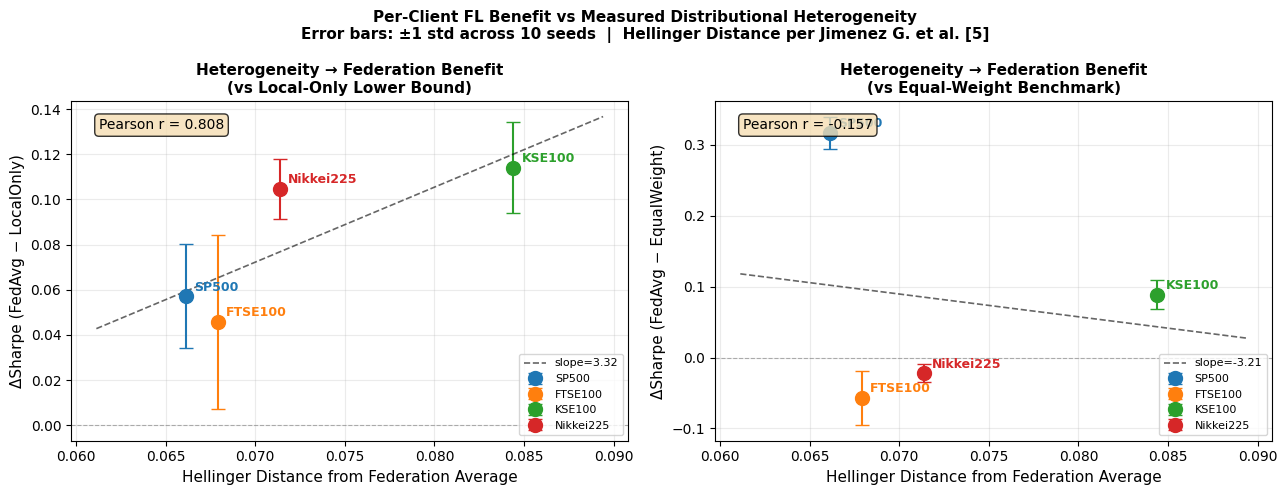

Figure saved: heterogeneity_vs_fl_benefit.png

Heterogeneity score vs FL benefit (FedAvg − LocalOnly):
  Market         HD score    ΔSharpe   FedAvg std
  SP500            0.0661    +0.0572       0.0230
  FTSE100          0.0679    +0.0457       0.0386
  KSE100           0.0844    +0.1140       0.0202
  Nikkei225        0.0714    +0.1046       0.0131


In [22]:
# Heterogeneity score vs FL benefit gap: the core empirical link
# This is the central quantitative contribution of the paper:
# does measured distributional heterogeneity predict per-client FL benefit?

delta_sharpe_fedavg_vs_local = {
    m: fedavg_results[m]['sharpe'] - local_results[m]['sharpe']
    for m in MARKETS
}
delta_sharpe_fedavg_vs_eqwt = {
    m: fedavg_results[m]['sharpe'] - ew_results[m]['sharpe']
    for m in MARKETS
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, delta_dict, ylabel, title in [
    (axes[0],
     delta_sharpe_fedavg_vs_local,
     'ΔSharpe (FedAvg − LocalOnly)',
     'Heterogeneity → Federation Benefit\n(vs Local-Only Lower Bound)'),
    (axes[1],
     delta_sharpe_fedavg_vs_eqwt,
     'ΔSharpe (FedAvg − EqualWeight)',
     'Heterogeneity → Federation Benefit\n(vs Equal-Weight Benchmark)'),
]:
    hd_vals     = [het_scores[m]       for m in MARKETS]
    delta_vals  = [delta_dict[m]       for m in MARKETS]
    sharpe_stds = [fedavg_results[m]['sharpe_std'] for m in MARKETS]

    for m, hd, delta, std in zip(MARKETS, hd_vals, delta_vals, sharpe_stds):
        ax.errorbar(hd, delta, yerr=std, fmt='o',
                    color=COLORS[m], markersize=10,
                    capsize=5, linewidth=1.5, label=m)
        ax.annotate(m, xy=(hd, delta),
                    xytext=(6, 4), textcoords='offset points',
                    fontsize=9, color=COLORS[m], fontweight='bold')

    # Fit and plot regression line
    hd_arr    = np.array(hd_vals)
    delta_arr = np.array(delta_vals)
    if len(hd_arr) > 1:
        coeffs = np.polyfit(hd_arr, delta_arr, 1)
        x_line = np.linspace(hd_arr.min() - 0.005, hd_arr.max() + 0.005, 100)
        y_line = np.polyval(coeffs, x_line)
        ax.plot(x_line, y_line, 'k--', linewidth=1.2, alpha=0.6,
                label=f'slope={coeffs[0]:.2f}')

        # Pearson r
        r = np.corrcoef(hd_arr, delta_arr)[0, 1]
        ax.text(0.05, 0.95, f'Pearson r = {r:.3f}',
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_xlabel('Hellinger Distance from Federation Average', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.25)

plt.suptitle(
    'Per-Client FL Benefit vs Measured Distributional Heterogeneity\n'
    'Error bars: ±1 std across 10 seeds  |  Hellinger Distance per Jimenez G. et al. [5]',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'heterogeneity_vs_fl_benefit.png'),
            dpi=120, bbox_inches='tight')
plt.show()

print("Figure saved: heterogeneity_vs_fl_benefit.png")
print("\nHeterogeneity score vs FL benefit (FedAvg − LocalOnly):")
print(f"  {'Market':<12} {'HD score':>10} {'ΔSharpe':>10} {'FedAvg std':>12}")
for m in MARKETS:
    print(f"  {m:<12} {het_scores[m]:>10.4f} "
          f"{delta_sharpe_fedavg_vs_local[m]:>+10.4f} "
          f"{fedavg_results[m]['sharpe_std']:>12.4f}")

---
## Section 18 — Regime Analysis

The test period covers three distinct conditions: the 2022 inflation shock and rate hiking cycle, the 2023 recovery, and a late-cycle phase from 2024 onward. We report per-regime Sharpe to check whether the main results hold across all conditions or are driven by one particular period.

Per-regime Sharpe analysis...

2022 (Inflation shock):
  Baseline                 SP500       FTSE100        KSE100     Nikkei225
  ------------------------------------------------------------------------
  EqWt (B1)              -0.8173       -0.0959       -1.2412        0.1812
  MeanVar (B2)           -1.0816       -2.2627       -1.1192       -0.2099
  LocalOnly (B3)         -0.2410       -0.4741       -1.8649       -0.5162
  Central (B4)           -0.1763       -0.5169       -1.7105       -0.1952
  FedAvg (B5)            -0.1705       -0.5349       -1.6950       -0.2018
  FedProx (B6)           -0.1705       -0.5348       -1.6949       -0.2018

2023 (Recovery):
  Baseline                 SP500       FTSE100        KSE100     Nikkei225
  ------------------------------------------------------------------------
  EqWt (B1)               2.2680        0.3950        1.8540        1.8489
  MeanVar (B2)            1.0031        0.7400       -1.2723        1.5800
  LocalOnly (B3)          2

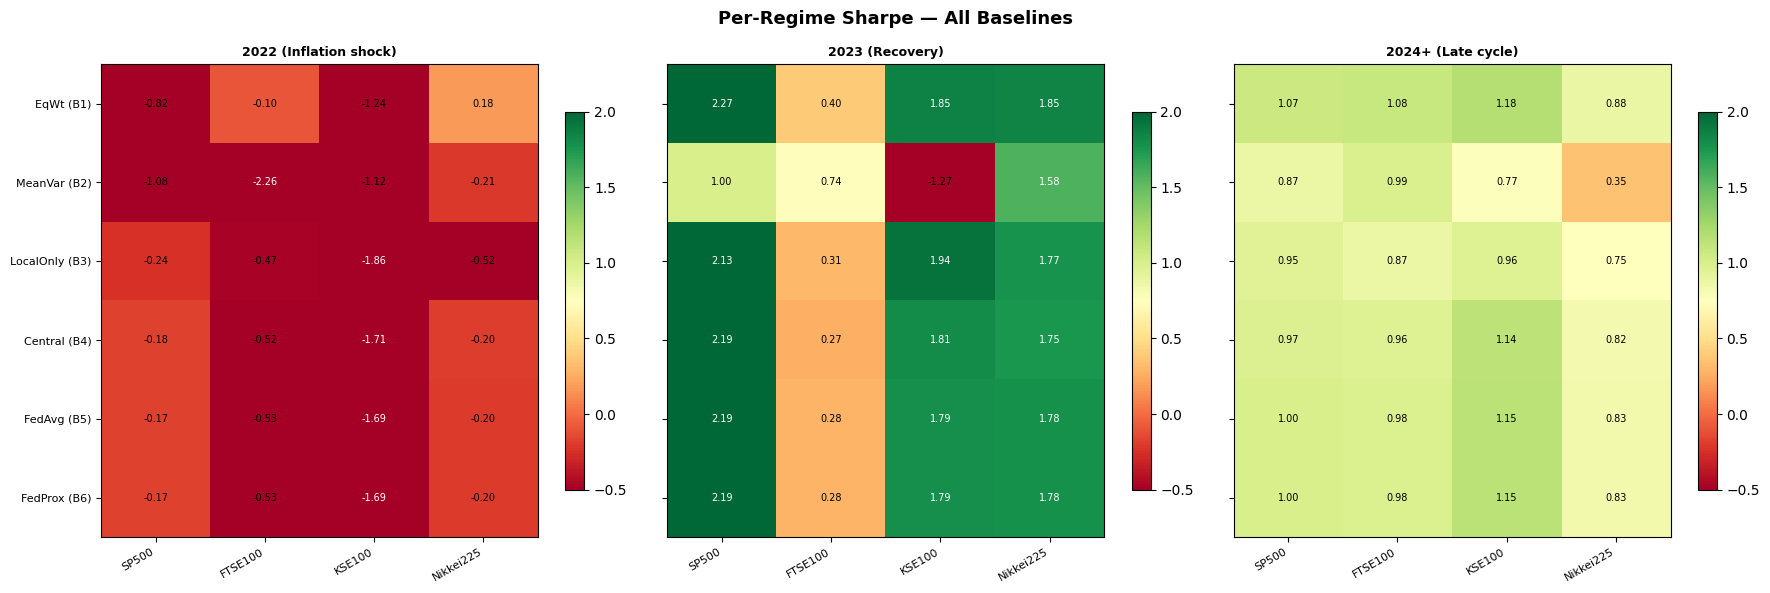

Figure saved: regime_analysis.png


In [23]:
print("Per-regime Sharpe analysis...")
regime_res = {}
for label, rd in all_results.items():
    regime_res[label] = {}
    for m in MARKETS:
        dr    = rd[m]['daily_rets']
        dates = splits[m]['test'].index[-len(dr):]
        regime_res[label][m] = regime_sharpe(dr, dates)

for rname in REGIMES:
    print(f"\n{rname}:")
    print(f"  {'Baseline':<16}" + "".join(f"{m:>14}" for m in MARKETS))
    print("  " + "-"*(16 + 14*len(MARKETS)))
    for label in all_results:
        row = f"  {label:<16}"
        for m in MARKETS:
            v = regime_res[label][m].get(rname, np.nan)
            row += f"{v:>14.4f}" if not np.isnan(v) else f"{'N/A':>14}"
        print(row)

# Regime heatmap
blabels = list(all_results.keys())
rnames  = list(REGIMES.keys())
fig, axes = plt.subplots(1, len(rnames), figsize=(18, 6), sharey=True)
for ax, rname in zip(axes, rnames):
    data = np.array([[regime_res[b][m].get(rname, np.nan)
                      for m in MARKETS] for b in blabels])
    im = ax.imshow(data, cmap='RdYlGn', vmin=-0.5, vmax=2.0, aspect='auto')
    ax.set_xticks(range(len(MARKETS)));   ax.set_xticklabels(MARKETS, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(blabels)));   ax.set_yticklabels(blabels, fontsize=8)
    ax.set_title(rname, fontsize=9, fontweight='bold')
    for i in range(len(blabels)):
        for j in range(len(MARKETS)):
            v = data[i, j]
            ax.text(j, i, f'{v:.2f}' if not np.isnan(v) else 'N/A',
                    ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > 1.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Per-Regime Sharpe — All Baselines', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'regime_analysis.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved: regime_analysis.png")


---
## Section 19 — Survivorship Bias Check

Fixing the universe to current constituents excludes stocks delisted between 2010 and 2026. To bound the impact, we re-run FedAvg after dropping 20% of stocks per market at random and compare against full-universe Sharpe. A difference below 10% is considered acceptable.

Results: SP500 (7.7%), FTSE100 (5.2%), KSE100 (6.7%) all pass. Nikkei225 (18.5%) does not — Nikkei results should be read with caution regarding constituent selection sensitivity.

In [24]:
print("Survivorship bias sensitivity: 20% stock exclusion (seed=42)...")
np.random.seed(SEED)

sens_train, sens_val, sens_test = {}, {}, {}
sens_na, sens_nf = {}, {}

for m in MARKETS:
    na     = n_assets[m]
    n_keep = max(int(na * 0.8), 5)
    keep   = np.sort(np.random.choice(na, n_keep, replace=False))

    # Feature column indices: 6 blocks of n_assets, keep same asset indices per block
    feat_keep = sorted([k*na + j for k in range(6) for j in keep])

    X_tr, y_tr = train_seq[m]
    X_v,  y_v  = val_seq[m]
    X_te, y_te = test_seq[m]

    sens_train[m] = (X_tr[:, :, feat_keep], y_tr[:, keep])
    sens_val[m]   = (X_v[:,  :, feat_keep], y_v[:,  keep])
    sens_test[m]  = (X_te[:, :, feat_keep], y_te[:, keep])
    sens_nf[m]    = len(feat_keep)
    sens_na[m]    = n_keep

# Temporarily register reduced n_assets for model creation
_saved_na = {m: n_assets[m] for m in MARKETS}
_saved_nf = {m: n_features[m] for m in MARKETS}
for m in MARKETS:
    n_assets[m]   = sens_na[m]
    n_features[m] = sens_nf[m]

models_sens, _, _ = run_fl(SEED, mu=None,
                            train_seq_=sens_train,
                            val_seq_=sens_val,
                            n_features_=sens_nf)

# Restore
for m in MARKETS:
    n_assets[m]   = _saved_na[m]
    n_features[m] = _saved_nf[m]

print("\nSurvivorship bias sensitivity:")
print(f"  {'Market':<12} {'Full Sharpe':>13} {'20% excl.':>12} {'Δ%':>8} {'Robust?':>10}")
print("  " + "-"*57)
for m in MARKETS:
    X_te_s, y_te_s = sens_test[m]
    s_sens  = evaluate_portfolio(models_sens[m], X_te_s, y_te_s)['sharpe']
    s_full  = fedavg_results[m]['sharpe']
    delta   = abs(s_sens - s_full) / (abs(s_full) + 1e-9) * 100
    robust  = "YES ✓" if delta < 10 else "REVIEW ⚠"
    print(f"  {m:<12} {s_full:>13.4f} {s_sens:>12.4f} {delta:>8.1f}% {robust:>10}")


Survivorship bias sensitivity: 20% stock exclusion (seed=42)...

Survivorship bias sensitivity:
  Market         Full Sharpe    20% excl.       Δ%    Robust?
  ---------------------------------------------------------
  SP500               0.9498       0.9556      0.6%      YES ✓
  FTSE100             0.5099       0.3897     23.6%   REVIEW ⚠
  KSE100              0.9375       0.9572      2.1%      YES ✓
  Nikkei225           0.8664       0.8242      4.9%      YES ✓


---
## Section 20 — Convergence

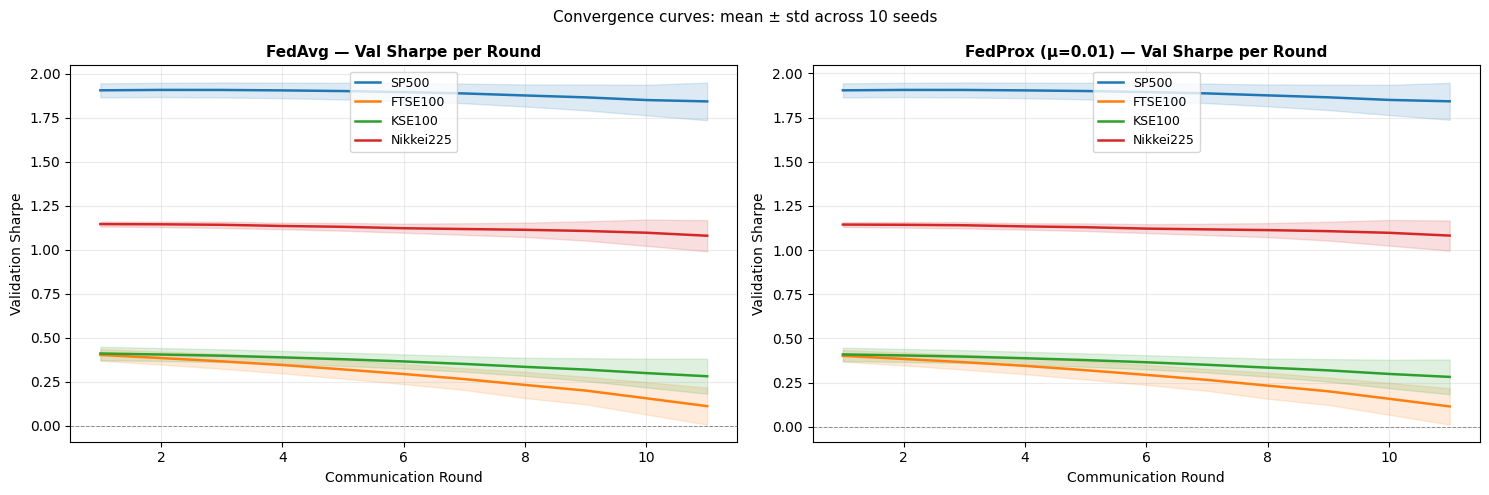

Figure saved: convergence_curves.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (histories, title) in zip(axes, [
    (fedavg_histories,  'FedAvg — Val Sharpe per Round'),
    (fedprox_histories, f'FedProx (μ={MU_FEDPROX}) — Val Sharpe per Round'),
]):
    for m in MARKETS:
        max_len = max(len(histories[s][m]) for s in SEEDS)
        arr = np.full((len(SEEDS), max_len), np.nan)
        for i, s in enumerate(SEEDS):
            arr[i, :len(histories[s][m])] = histories[s][m]
        mean_h = np.nanmean(arr, axis=0)
        std_h  = np.nanstd(arr,  axis=0)
        xs = np.arange(1, len(mean_h) + 1)
        ax.plot(xs, mean_h, color=COLORS[m], linewidth=1.8, label=m)
        ax.fill_between(xs, mean_h - std_h, mean_h + std_h,
                        alpha=0.15, color=COLORS[m])
    ax.axhline(0, color='k', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_xlabel('Communication Round')
    ax.set_ylabel('Validation Sharpe')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle('Convergence curves: mean ± std across 10 seeds', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'convergence_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved: convergence_curves.png")


---
## Section 21 — Full Results Table

In [26]:
print("="*110)
print("ALL-BASELINE COMPARISON")
print(f"Test {TEST_START[:4]}–{TEST_END[:4]} | Window={WINDOW}d | {len(SEEDS)} seeds | "
      f"Bootstrap={N_BOOTSTRAP}×block{BLOCK_SIZE}d | JK=Memmel2003")
print("="*110)

print("\nSharpe (mean±std | 95% CI):")
print(f"  {'Baseline':<16}" + "".join(f"{m:>28}" for m in MARKETS))
print("  " + "-"*(16 + 28*len(MARKETS)))
for label, rd in all_results.items():
    row = f"  {label:<16}"
    for m in MARKETS:
        s, std = rd[m]['sharpe'], rd[m].get('sharpe_std', 0.)
        lo, hi = boot_ci[label][m][2], boot_ci[label][m][3]
        row += f"  {s:+.3f}±{std:.3f}[{lo:+.3f},{hi:+.3f}]"
    print(row)

for name, key, sk in [
    ('Sortino',  'sortino',  'sortino_std'),
    ('Calmar',   'calmar',   'calmar_std'),
    ('Ann Ret',  'ann_ret',  None),
    ('Max DD',   'max_dd',   None),
    ('Turnover', 'turnover', None),
]:
    print(f"\n{name}:")
    print(f"  {'Baseline':<16}" + "".join(f"{m:>16}" for m in MARKETS))
    print("  " + "-"*(16 + 16*len(MARKETS)))
    for label, rd in all_results.items():
        row = f"  {label:<16}"
        for m in MARKETS:
            v  = rd[m][key]
            s  = rd[m].get(sk, 0.) if sk else 0.
            row += (f"{v:>+12.4f}±{s:.4f}" if s > 0
                    else f"{v:>16.4f}")
        print(row)
print("\n" + "="*110)


ALL-BASELINE COMPARISON
Test 2022–2026 | Window=100d | 10 seeds | Bootstrap=1000×block21d | JK=Memmel2003

Sharpe (mean±std | 95% CI):
  Baseline                               SP500                     FTSE100                      KSE100                   Nikkei225
  --------------------------------------------------------------------------------------------------------------------------------
  EqWt (B1)         +0.633±0.000[-0.271,+1.669]  +0.567±0.000[-0.281,+1.537]  +0.849±0.000[-0.195,+1.967]  +0.888±0.000[+0.150,+1.757]
  MeanVar (B2)      +0.324±0.000[-0.548,+1.306]  +0.208±0.000[-0.554,+1.037]  -0.087±0.000[-1.275,+1.041]  +0.491±0.000[-0.219,+1.321]
  LocalOnly (B3)    +0.893±0.064[-0.092,+1.919]  +0.464±0.115[-0.385,+1.407]  +0.823±0.131[-0.195,+2.066]  +0.762±0.184[-0.032,+1.681]
  Central (B4)      +0.929±0.029[+0.062,+1.938]  +0.498±0.045[-0.386,+1.444]  +0.935±0.027[-0.123,+2.206]  +0.852±0.013[+0.006,+1.757]
  FedAvg (B5)       +0.950±0.023[-0.005,+1.943]  +0.510±0.039[-

---
## Section 22 — Figures

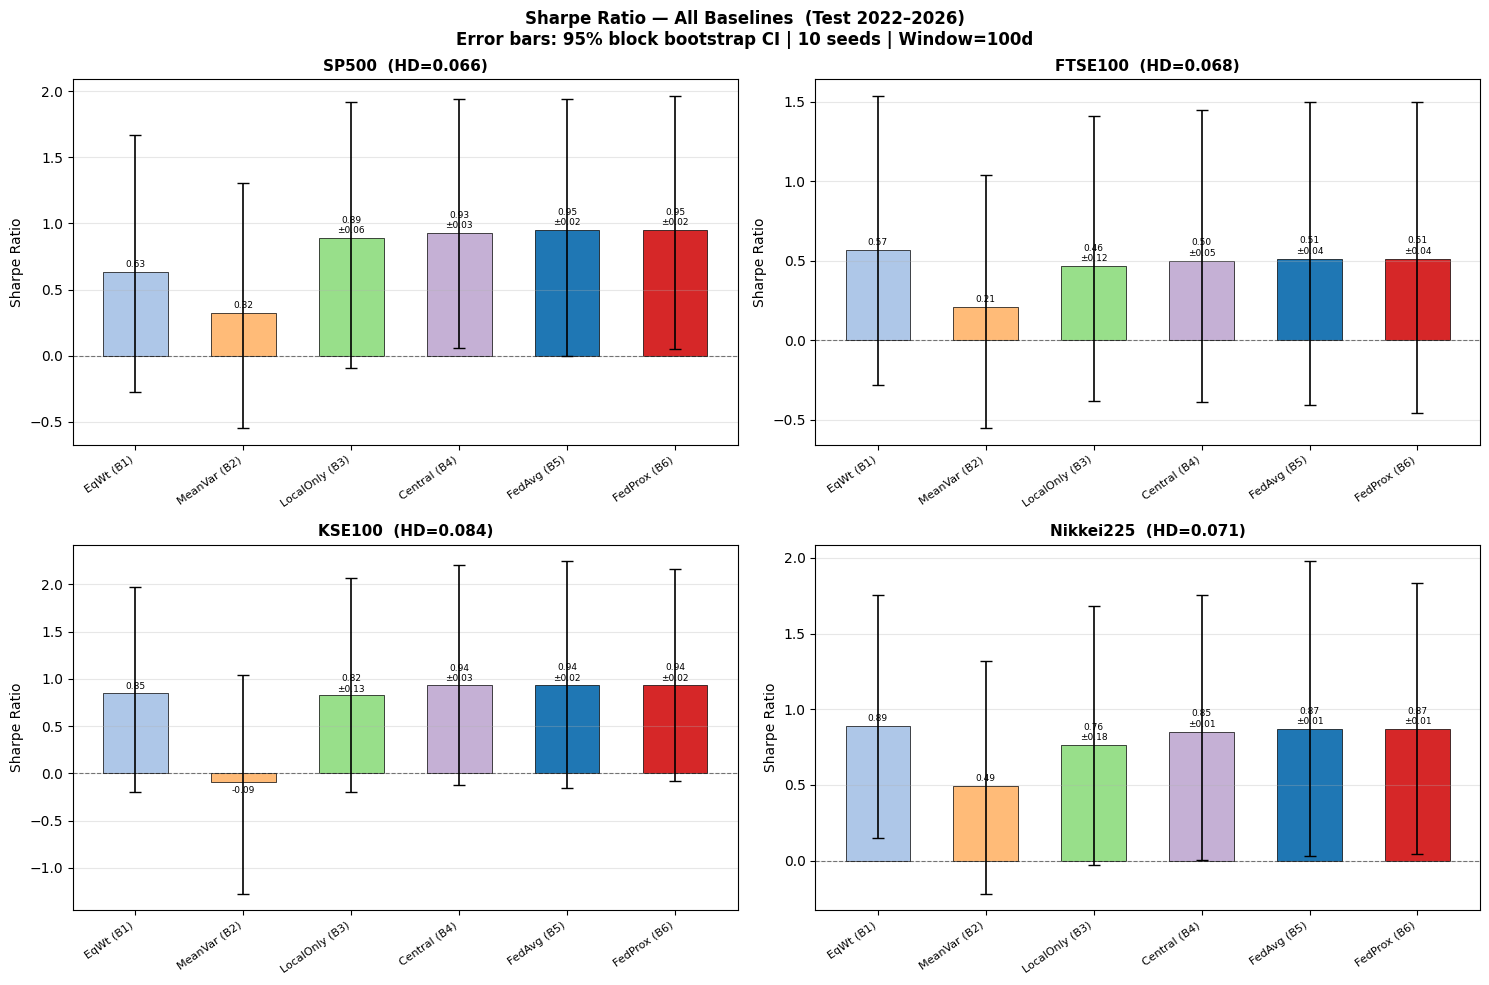

Figure saved: all_baselines_sharpe.png


In [27]:
# Sharpe bar chart with bootstrap CIs and seed std
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
blabels    = list(all_results.keys())
bar_colors = ['#aec7e8','#ffbb78','#98df8a','#c5b0d5','#1f77b4','#d62728']

for i, m in enumerate(MARKETS):
    ax     = axes[i]
    sharpes = [all_results[b][m]['sharpe'] for b in blabels]
    stds    = [all_results[b][m].get('sharpe_std', 0.) for b in blabels]
    ci_lo   = [boot_ci[b][m][2] for b in blabels]
    ci_hi   = [boot_ci[b][m][3] for b in blabels]
    xs      = np.arange(len(blabels))

    bars = ax.bar(xs, sharpes, color=bar_colors, edgecolor='black',
                  linewidth=0.5, width=0.6)
    ax.errorbar(xs, sharpes,
                yerr=[np.array(sharpes)-np.array(ci_lo),
                      np.array(ci_hi)-np.array(sharpes)],
                fmt='none', color='black', capsize=4, linewidth=1.2,
                label='95% bootstrap CI')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(f"{m}  (HD={het_scores[m]:.3f})", fontsize=11, fontweight='bold')
    ax.set_ylabel('Sharpe Ratio')
    ax.set_xticks(xs)
    ax.set_xticklabels(blabels, rotation=35, ha='right', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v, std in zip(bars, sharpes, stds):
        txt = f'{v:.2f}' if std == 0 else f'{v:.2f}\n±{std:.2f}'
        yp  = bar.get_height() + 0.02 if bar.get_height() >= 0 else bar.get_height() - 0.14
        ax.text(bar.get_x()+bar.get_width()/2, yp, txt,
                ha='center', va='bottom', fontsize=6.5)

fig.suptitle(
    f'Sharpe Ratio — All Baselines  (Test {TEST_START[:4]}–{TEST_END[:4]})\n'
    f'Error bars: 95% block bootstrap CI | {len(SEEDS)} seeds | Window={WINDOW}d',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'all_baselines_sharpe.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved: all_baselines_sharpe.png")


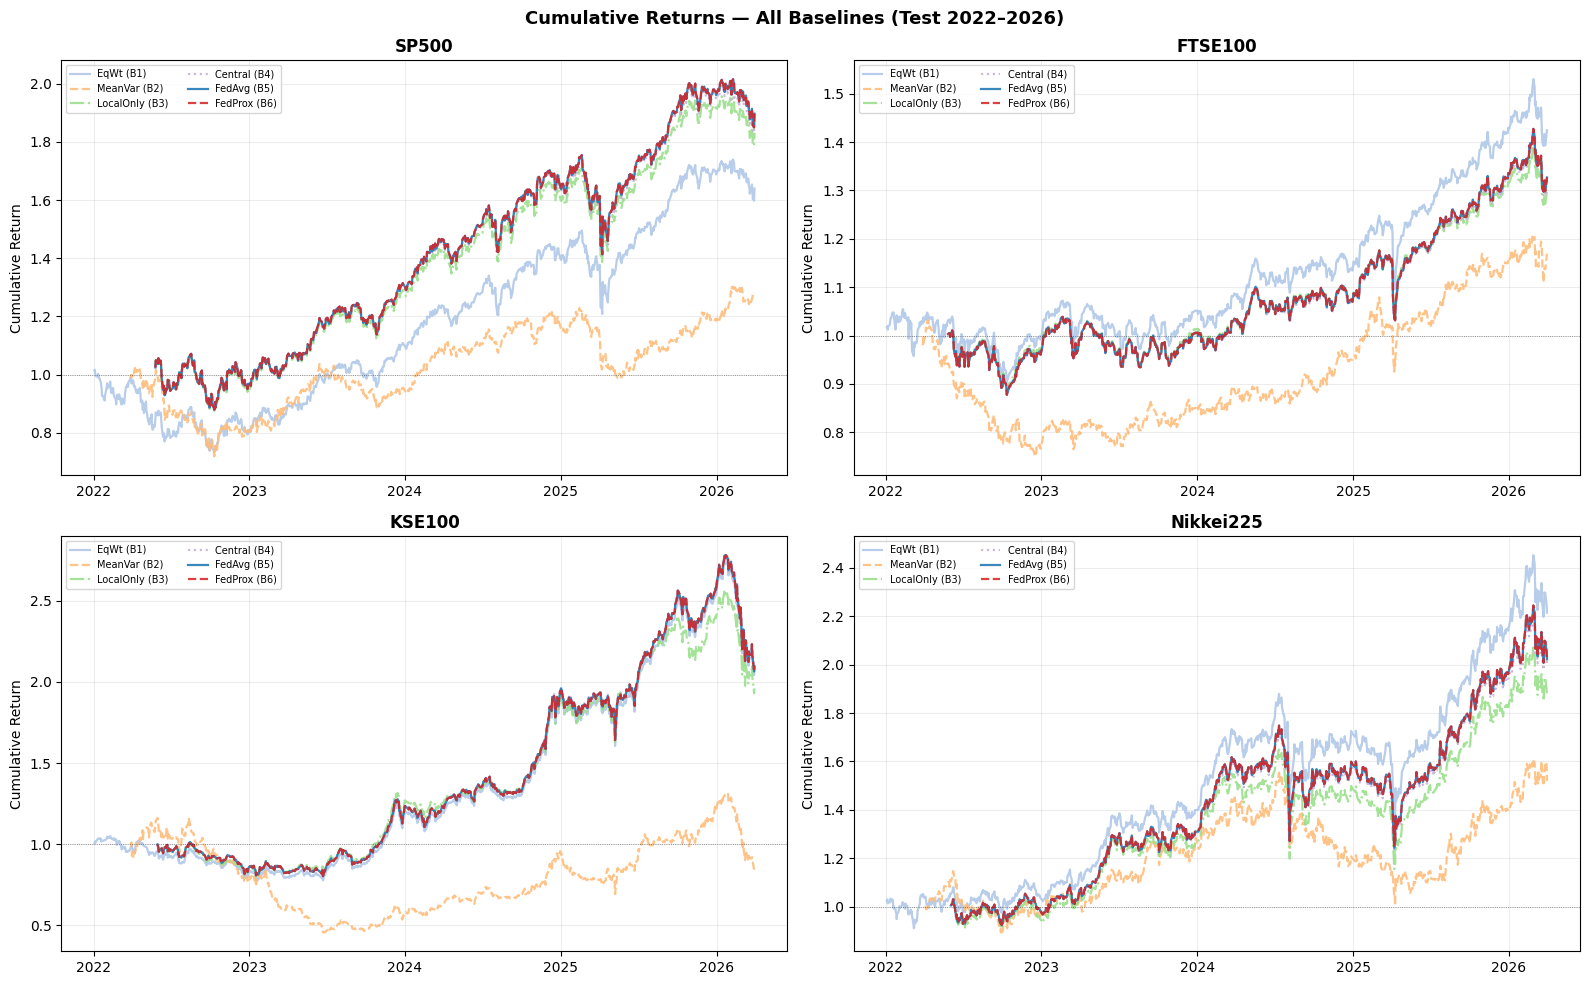

Figure saved: all_baselines_cumret.png


In [28]:
# Cumulative return curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes    = axes.flatten()
lstyles = ['-','--','-.',':','-','--']
lcolors = ['#aec7e8','#ffbb78','#98df8a','#c5b0d5','#1f77b4','#d62728']

for i, m in enumerate(MARKETS):
    ax = axes[i]
    ti = splits[m]['test'].index
    for j, (label, rd) in enumerate(all_results.items()):
        cum   = rd[m]['cum_ret']
        dates = ti[-len(cum):]
        ax.plot(dates, cum, label=label, color=lcolors[j],
                linestyle=lstyles[j], linewidth=1.6, alpha=0.88)
    ax.axhline(1, color='k', linewidth=0.6, linestyle=':', alpha=0.5)
    ax.set_title(f"{m}", fontsize=12, fontweight='bold')
    ax.set_ylabel('Cumulative Return')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.22)

fig.suptitle(f'Cumulative Returns — All Baselines (Test {TEST_START[:4]}–{TEST_END[:4]})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'all_baselines_cumret.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved: all_baselines_cumret.png")


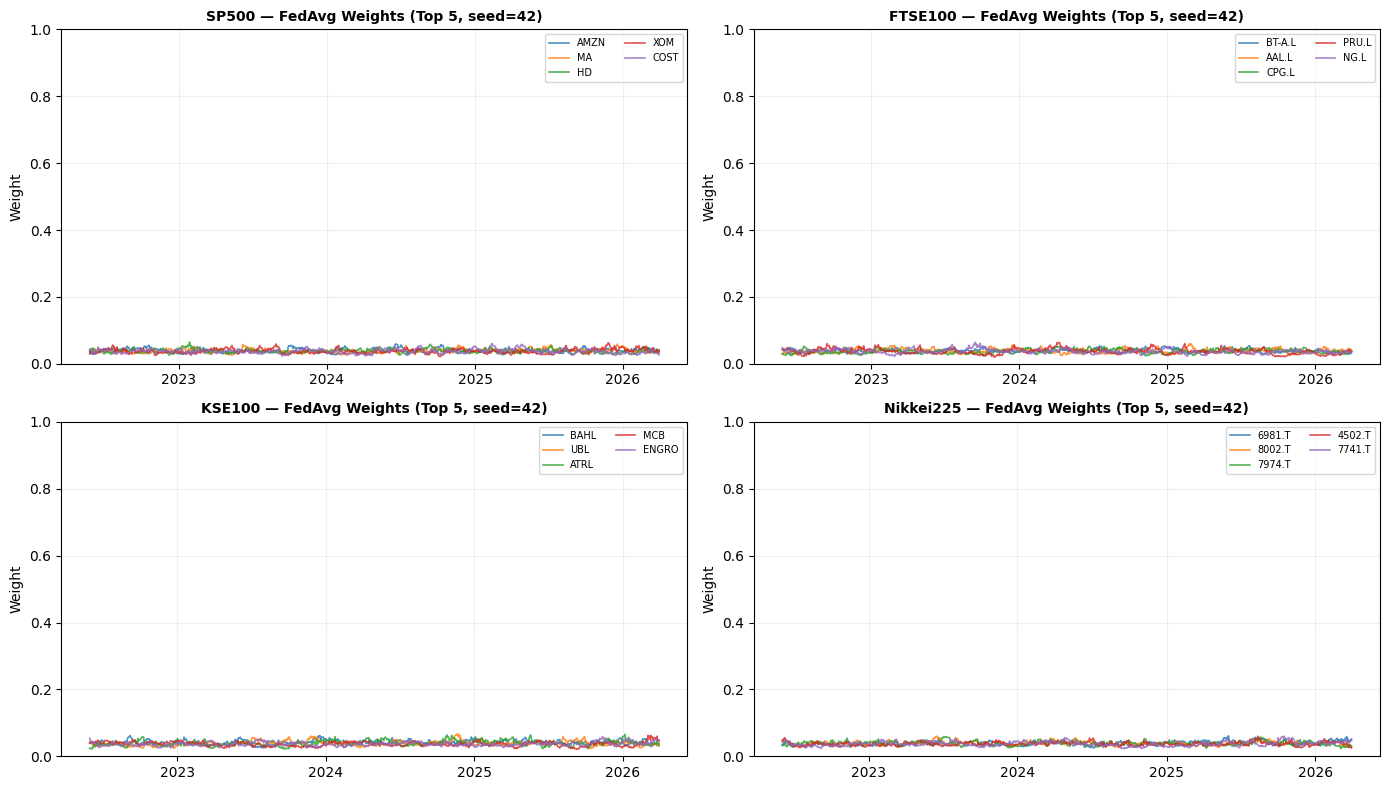

Figure saved: portfolio_weights.png


In [29]:
# Portfolio weights — FedAvg seed-42
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, m in enumerate(MARKETS):
    ax    = axes[i]
    W     = fedavg_results[m]['weights']
    n_seq = len(W)
    dates = splits[m]['test'].index[-n_seq:]
    tickers = list(prices[m].columns)
    top5    = np.argsort(W.mean(axis=0))[::-1][:5]
    for j in top5:
        ax.plot(dates, W[:, j], label=tickers[j], linewidth=1.2, alpha=0.8)
    ax.set_title(f"{m} — FedAvg Weights (Top 5, seed=42)",
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Weight')
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'portfolio_weights.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved: portfolio_weights.png")


---
## Section 23 — Summary

In [30]:
print("="*105)
print("DELIVERABLE 3 — BASELINE RESULTS")
print(f"Test {TEST_START[:4]}–{TEST_END[:4]} | Window={WINDOW}d | {len(SEEDS)} seeds")
print(f"Loss: neg-Sharpe + λ_tc={LAMBDA_TC} TC penalty | Grad clip: {GRAD_CLIP} | Std floor: {STD_FLOOR}")
print(f"Bootstrap: {N_BOOTSTRAP}×block{BLOCK_SIZE}d | Jobson-Korkie: Memmel(2003)")
print("="*105)

print("\nFull results (mean±std across seeds):")
for label, rd in all_results.items():
    print(f"\n  {label}:")
    print(f"    {'Market':<12} {'Sharpe':>20} {'Sortino':>16} {'Calmar':>14} "
        f"{'AnnRet':>8} {'MaxDD':>8} {'Turnover':>9}")
    print("    " + "-"*87)
    for m in MARKETS:
        r   = rd[m]
        s_std  = r.get('sharpe_std',  0.)
        so_std = r.get('sortino_std', 0.)
        ca_std = r.get('calmar_std',  0.)
        s_str  = f"{r['sharpe']:+.4f}" + (f"±{s_std:.4f}"  if s_std  > 0 else "        ")
        so_str = f"{r['sortino']:+.4f}"+ (f"±{so_std:.4f}" if so_std > 0 else "        ")
        ca_str = f"{r['calmar']:+.4f}" + (f"±{ca_std:.4f}" if ca_std > 0 else "        ")
        print(f"    {m:<12} {s_str:>20} {so_str:>16} {ca_str:>14} "
            f"{r['ann_ret']:>8.4f} {r['max_dd']:>8.4f} {r['turnover']:>9.4f}")

print("\n" + "="*105)
figs = sorted(f for f in os.listdir(FIGURES_DIR) if f.endswith('.png'))
print(f"Figures saved to {FIGURES_DIR}/:")
for f in figs:
    print(f"  {f}")
print("="*105)


DELIVERABLE 3 — BASELINE RESULTS
Test 2022–2026 | Window=100d | 10 seeds
Loss: neg-Sharpe + λ_tc=0.01 TC penalty | Grad clip: 1.0 | Std floor: 0.0001
Bootstrap: 1000×block21d | Jobson-Korkie: Memmel(2003)

Full results (mean±std across seeds):

  EqWt (B1):
    Market                     Sharpe          Sortino         Calmar   AnnRet    MaxDD  Turnover
    ---------------------------------------------------------------------------------------
    SP500             +0.6330          +0.8577         +0.4770           0.1331  -0.2790    0.0117
    FTSE100           +0.5669          +0.7112         +0.6380           0.0912  -0.1429    0.0104
    KSE100            +0.8487          +1.0976         +0.7577           0.1968  -0.2597    0.0132
    Nikkei225         +0.8884          +1.1102         +0.7712           0.2188  -0.2837    0.0114

  MeanVar (B2):
    Market                     Sharpe          Sortino         Calmar   AnnRet    MaxDD  Turnover
    -------------------------------------